# 07 · Co-Scientist — Accelerating scientific discovery with Co-Scientist

**Paper:** Gottweis, Weng, Daryin, Tu, Sirkovic, Myaskovsky, … Natarajan (Google Cloud AI Research / Google DeepMind / Google Research). arXiv [2502.18864](https://arxiv.org/abs/2502.18864) (`papers/2502.18864.pdf`).

**Code status: re-implemented.** The paper's "Code availability" section states plainly that *"The full source code for the Co-Scientist system is not publicly available"*; instead the authors published pseudocode for the multi-agent orchestration and tournament logic (Supplementary Note 8) and the exact agent prompts (Supplementary Note 9). This notebook therefore contains a **standalone re-implementation** in `notebooks/coscientist/`, written against the Methods section, that pseudocode and those prompts. The agent prompts below are reproduced from Supplementary Note 9 close to verbatim (with the paper's `{goal}` / `{preferences}` / `{idea_attributes}` slots) and adapted only where an output must be machine-parseable. Every LLM call goes through `common.chat` / `common.chat_json` on the project's OpenRouter model.

**Research goal.** Instead of the paper's biomedical goals we use this repository's own domain, so the notebook exercises the same machinery on a problem the RCP platform actually simulates:

> *How can a data center reduce its power usage effectiveness (PUE) and cooling energy without raising server inlet temperature above 27 °C?*

**Literature grounding.** The Generation / Reflection / Evolution agents call `coscientist.literature.search`, which tries Semantic Scholar's public graph API (no key, aggressively rate-limited — retries with exponential backoff) and falls back to OpenAlex, the two sources the RCP platform's Research Memory uses. If both fail the agents run ungrounded and the notebook says so.

| § | Building block | Paper reference | Code |
|---|---|---|---|
| 1 | Research plan configuration; Supervisor, asynchronous task queue, summary statistics → weighted agent sampling | Methods "Overview of Co-Scientist architecture"; Supp. Note 8 (`StartCoScientist`, `ManageFollowUpTasks`, `DecideNextSteps`); Supp. Note 10.1 | `supervisor.py`, `state.py` |
| 2 | Generation agent: literature exploration, simulated scientific debate, iterative assumptions identification, research expansion | Methods "Generation agent"; Supp. Note 9.1 | `generation.py` |
| 3 | Reflection agent: initial / full / deep verification / observation / simulation / tournament review | Methods "Reflection agent"; Supp. Note 9.2, 10.3–10.8 | `reflection.py` |
| 4 | Ranking agent: Elo tournament, single-turn comparison and multi-turn scientific debate, proximity-aware pairing | Methods "Ranking agent"; Supp. Note 9.3, 10.9 | `ranking.py` |
| 5 | Proximity agent: similarity graph, clustering, de-duplication | Methods "Proximity agent" | `proximity.py` |
| 6 | Evolution agent: grounding, feasibility, inspiration, combination, simplification, out-of-the-box | Methods "Evolution agent"; Supp. Note 9.4 | `evolution.py` |
| 7 | Meta-review agent: critique synthesis fed back into agent prompts; research overview | Methods "Meta-review agent"; Supp. Note 9.5, 10.10, 10.11 | `metareview.py` |
| 8 | Test-time compute scaling (Elo vs. compute) + "generate only" ablation | Fig. 2a; Methods "Ablation analysis" | `supervisor.py`, `ranking.joint_tournament` |
| 9 | LIVE `pi` session: Reflection agent doing deep verification with a real calculation | Methods "Deep verification review", "Tool use in Co-Scientist" | `common.run_pi` |

Set `NB_QUICK=1` for smaller budgets (fewer rounds, fewer matches, shorter debates).

In [1]:
import os, sys, json, time, math, random, textwrap
sys.path.insert(0, os.path.abspath("."))
os.environ.setdefault("TQDM_DISABLE", "1")
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
common.banner()

from coscientist import (state as cs_state, literature as lit, generation as gen, reflection as ref,
                         ranking as rank, proximity as prox, evolution as evo, metareview as meta,
                         supervisor as sup)
from coscientist.state import Memory, ResearchPlan, Hypothesis, EloTable, TaskQueue, simulate_elo

OUT = OUTPUT_DIR / "coscientist"; OUT.mkdir(exist_ok=True)
GOAL = ("How can a data center reduce its power usage effectiveness (PUE) and cooling energy "
        "without raising server inlet temperature above 27 °C?")
print("QUICK =", QUICK)
print("goal:", GOAL)

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

QUICK = False
goal: How can a data center reduce its power usage effectiveness (PUE) and cooling energy without raising server inlet temperature above 27 °C?


## 1 · Research plan configuration and the Supervisor (Methods; Supp. Note 8, 10.1)

> "Co-Scientist then parses the goal to derive a **research plan configuration** for generating research proposals. This configuration captures the desired proposal preferences, attributes, and constraints. … These criteria are then used by the system during its auto-evaluation, tournament debates and self-improvement phases."

> "A dedicated **Supervisor agent** manages the worker task queue, assigns specialized agents to these processes, and allocates resources. … Periodically, the Supervisor agent calculates a comprehensive set of summary statistics, reflecting the system's state and progress toward the specified research goal. … Based on these statistics, the Supervisor agent then orchestrates subsequent system operations … **by strategically weighting and sampling the specialized agents** for execution via the worker processes."

Supplementary Note 10.1 shows the parsed configuration as *preferences / attributes / constraints*; we parse into exactly those fields plus the `idea_attributes` slot that the paper's Generation and Ranking prompts interpolate.

In [2]:
show_source(sup.parse_research_plan)
PLAN = sup.parse_research_plan(GOAL)
md("**Parsed research plan configuration**")
display(df([{"field": k, "value": v if isinstance(v, str) else " · ".join(map(str, v))}
            for k, v in PLAN.to_dict().items()]))

**parse_research_plan**

```python
def parse_research_plan(goal: str) -> ResearchPlan:
    obj = common.chat_json(PLAN_PROMPT.format(goal=goal),
                           "You configure a multi-agent scientific discovery system.",
                           tag="sup.plan", max_tokens=1200,
                           validate=lambda o: o["preferences"] and o["constraints"])
    prefs = [str(p) for p in obj["preferences"]] + [str(c) for c in obj.get("evaluation_criteria", [])]
    return ResearchPlan(goal=goal, preferences=prefs,
                        attributes=[str(a) for a in obj.get("attributes", [])],
                        constraints=[str(c) for c in obj["constraints"]],
                        idea_attributes=str(obj.get("idea_attributes", "novel and feasible")),
                        notes=str(obj.get("notes", "")))

```

**Parsed research plan configuration**

,field,value
0,goal,How can a data center reduce its power usage e...
1,preferences,deployability · energy efficiency · cost-effec...
2,attributes,Novelty · Feasibility · Impact on PUE · Coolin...
3,constraints,server inlet temperature must not exceed 27 °C
4,idea_attributes,"novel, feasible, and impactful"
5,notes,"Focus on practical, deployable solutions that ..."


### 1.1 · The asynchronous task queue and the weighting rule

The queue itself is the `GlobalTaskQueue` of Supplementary Note 8: a priority queue with FIFO
tie-breaking. Two things push tasks onto it:

* **`ManageFollowUpTasks`** — the workflow chain. A new hypothesis ⇒ a `Reflection.ReviewHypothesis`
  task; a completed review ⇒ a `Ranking.AddToTournament` task. These enter at high priority.
* **`DecideNextSteps`** — what to do when the workflow produces nothing. The pseudocode is a chain of
  `IF`s ("keep the tournament running"; "if hypothesis quality has stopped improving, evolve the top
  ideas"; "if enough time has passed, synthesize system-wide feedback"). We implement it as the paper
  describes it in the Methods text — a **soft policy**: the statistics are turned into per-agent
  weights and the Supervisor *samples* agents from them.

`agent_weights` is pure Python, so its behaviour can be pinned down on hand-built statistics.

In [3]:
show_source(sup.agent_weights)

**agent_weights**

```python
def agent_weights(s: SystemStatistics, cfg: SupervisorConfig) -> dict[str, float]:
    """Turn the statistics into sampling weights for the specialised agents.

    Encodes DecideNextSteps of Supplementary Note 8 as a soft policy rather than a hard if-chain:
      * reflection scales with the unreviewed backlog (nothing enters the tournament unreviewed);
      * ranking scales with the deficit of matches per idea ("keep the tournament running");
      * generation decays as the population approaches MaxIdeas;
      * evolution turns on when the top Elo has stopped improving ("if scores are stable, try to
        improve top ideas") and is boosted when evolved ideas are winning their matches;
      * proximity turns on when the graph is stale (missing edges);
      * meta-review fires periodically ("if enough time has passed").
    """
    room = max(0.0, 1.0 - s.n_hypotheses / max(1, cfg.max_ideas))
    deficit = max(0.0, 1.0 - s.matches_per_idea / cfg.target_matches_per_idea)
    stalled = 1.0 if (s.round > 0 and s.top_elo_gain < cfg.stall_tol) else 0.0
    w = {
        "generation": 0.15 + 1.8 * room,
        "reflection": 0.05 + 1.5 * min(1.0, s.n_unreviewed / 3.0),
        "ranking": 0.20 + 2.0 * deficit,
        "proximity": 0.05 + 1.2 * min(1.0, s.missing_edges / 6.0),
        "evolution": 0.10 + 1.4 * stalled * (0.6 + s.evo_win_rate) * (1.0 if s.n_in_tournament >= 2 else 0.0),
        "metareview": 1.2 if s.rounds_since_metareview >= cfg.metareview_period and s.n_active >= 2 else 0.05,
    }
    return {k: round(v, 3) for k, v in w.items()}

```

In [4]:
cfg_demo = sup.SupervisorConfig(max_ideas=12, target_matches_per_idea=3.0, metareview_period=2)
cases = {
 "cold start (nothing exists)":        sup.SystemStatistics(round=0),
 "4 hypotheses, none reviewed":        sup.SystemStatistics(round=1, n_hypotheses=4, n_active=4, n_unreviewed=4, missing_edges=6, rounds_since_metareview=1),
 "reviewed, tournament untouched":     sup.SystemStatistics(round=2, n_hypotheses=4, n_active=4, n_in_tournament=4, matches_per_idea=0.0, missing_edges=6, rounds_since_metareview=2),
 "tournament saturated, Elo climbing": sup.SystemStatistics(round=5, n_hypotheses=8, n_active=8, n_in_tournament=8, matches_per_idea=3.4, top_elo=1290, top_elo_gain=25, rounds_since_metareview=1),
 "tournament saturated, Elo STALLED":  sup.SystemStatistics(round=6, n_hypotheses=8, n_active=8, n_in_tournament=8, matches_per_idea=3.4, top_elo=1291, top_elo_gain=1, rounds_since_metareview=1, evo_win_rate=0.6),
 "population at MaxIdeas":             sup.SystemStatistics(round=9, n_hypotheses=12, n_active=12, n_in_tournament=12, matches_per_idea=3.5, top_elo=1330, top_elo_gain=2, rounds_since_metareview=3, evo_win_rate=0.55),
}
display(df([{"situation": k, **sup.agent_weights(v, cfg_demo)} for k, v in cases.items()]).set_index("situation"))
md("Reading the table: reflection dominates while a review backlog exists; ranking dominates while "
   "matches/idea is below target; **evolution only switches on once the top Elo stops improving** "
   "(the paper's *\"if scores are stable, try to improve top ideas\"*); generation decays as the "
   "population approaches `MaxIdeas`; meta-review fires on its period.")

,generation,reflection,ranking,proximity,evolution,metareview
situation,,,,,,
cold start (nothing exists),1.95,0.05,2.2,0.05,0.10,0.05
"4 hypotheses, none reviewed",1.35,1.55,2.2,1.25,0.10,0.05
"reviewed, tournament untouched",1.35,0.05,2.2,1.25,0.94,1.20
"tournament saturated, Elo climbing",0.75,0.05,0.2,0.05,0.10,0.05
"tournament saturated, Elo STALLED",0.75,0.05,0.2,0.05,1.78,0.05
population at MaxIdeas,0.15,0.05,0.2,0.05,1.71,1.20


Reading the table: reflection dominates while a review backlog exists; ranking dominates while matches/idea is below target; **evolution only switches on once the top Elo stops improving** (the paper's *"if scores are stable, try to improve top ideas"*); generation decays as the population approaches `MaxIdeas`; meta-review fires on its period.

### 1.2 · The queue evolving over rounds

To show the scheduler on its own — before spending any model calls on it — we run the real
`Supervisor` loop against `DryRunAgents`: deterministic stand-ins that create placeholder
hypotheses, accept/reject them, and play synthetic tournament matches. The queue, the statistics,
the weights and the follow-up chain are the same code paths §8 will run for real.

In [5]:
show_source(sup.Supervisor.step)

**Supervisor.step**

```python
    def step(self) -> dict:
        stats = compute_stats(self.memory, self.round, self.last_metareview, self.prev_top)
        weights = agent_weights(stats, self.cfg)
        sampled = self.fill_queue(stats)
        # AddToTournament is O(1) bookkeeping (Supp. Note 8) and does not occupy a worker slot
        batch, cheap = [], []
        while len(batch) < self.cfg.slots_per_round:
            t = self.queue.pop()
            if t is None:
                break
            (cheap if t.action == "AddToTournament" else batch).append(t)
        for t in cheap:
            self.agents.execute(self, t)
            self.queue.completed.append(t)
        if self.verbose and batch:
            print(f"round {self.round}: running {[t.label() for t in batch]}")

        def run(t: Task):
            try:
                return t, self.agents.execute(self, t)
            except Exception as exc:                      # a failing worker must not kill the loop
                return t, TaskResult("Failed", [], f"{type(exc).__name__}: {exc}")

        with ThreadPoolExecutor(max_workers=self.cfg.workers) as ex:
            done = list(ex.map(run, batch))
        for t, res in done:
            self.queue.completed.append(t)
            if res.kind == "Failed" and self.verbose:
                print(f"  ! {t.label()} failed: {res.info[:200]}")
            self.manage_followups(res)
            if t.agent == "metareview" and res.kind != "Failed":
                self.last_metareview = self.round
        self.prev_top = stats.top_elo
        rec = {**stats.row(), "weights": weights, "sampled": sampled,
               "executed": [t.label() for t in batch] + [f"·{t.label()}" for t in cheap],
               "queue after": self.queue.counts(), "queue len": len(self.queue)}
        self.log.append(rec)
        self.round += 1
        return rec

```

In [6]:
dry_mem = Memory(OUT / "dryrun", PLAN)
dry = sup.Supervisor(dry_mem, PLAN, sup.DryRunAgents(seed=1),
                     sup.SupervisorConfig(max_ideas=12, slots_per_round=4, matches_per_round=6), seed=3)
dry.queue.push("generation", "CreateInitialHypotheses", priority=0)   # StartCoScientist
log = dry.run(7)
cols = ["round", "hyps", "active", "unreviewed", "in tournament", "matches/idea", "top Elo",
        "ΔtopElo", "since meta", "queue len"]
md("**System statistics per round** (what the Supervisor writes to context memory)")
display(df([{c: r[c] for c in cols} for r in log]).set_index("round"))
md("**Sampled agents and the tasks actually executed** (`·` marks O(1) bookkeeping tasks that do not occupy a worker slot)")
display(df([{"round": r["round"], "sampled": ", ".join(r["sampled"]) or "—",
             "executed": ", ".join(r["executed"]), "queue after": str(r["queue after"])} for r in log]).set_index("round"))

round 0: running ['generation.CreateInitialHypotheses', 'generation.GenerateHypothesis', 'ranking.RunTournamentBatch', 'generation.GenerateHypothesis']
round 1: running ['reflection.ReviewHypothesis(H01)', 'reflection.ReviewHypothesis(H02)', 'reflection.ReviewHypothesis(H03)', 'reflection.ReviewHypothesis(H04)']
round 2: running ['ranking.RunTournamentBatch', 'ranking.RunTournamentBatch', 'generation.GenerateHypothesis', 'generation.GenerateHypothesis']
round 3: running ['reflection.ReviewHypothesis(H05)', 'reflection.ReviewHypothesis(H06)', 'ranking.RunTournamentBatch', 'metareview.GenerateSystemFeedback']
round 4: running ['ranking.RunTournamentBatch', 'reflection.ReviewHypothesis', 'generation.GenerateHypothesis', 'metareview.GenerateSystemFeedback']
round 5: running ['reflection.ReviewHypothesis(H07)', 'ranking.RunTournamentBatch', 'proximity.UpdateProximityGraph', 'proximity.UpdateProximityGraph']
round 6: running ['ranking.RunTournamentBatch', 'evolution.EvolveTopHypotheses', 'ev

**System statistics per round** (what the Supervisor writes to context memory)

,hyps,active,unreviewed,in tournament,matches/idea,top Elo,ΔtopElo,since meta,queue len
round,,,,,,,,,
0,0,0,0,0,0.0,1200.0,0.0,2,4
1,4,4,4,0,0.0,1200.0,0.0,3,6
2,4,4,0,0,0.0,1200.0,0.0,4,2
3,6,6,2,4,4.0,1226.8,26.8,5,2
4,6,5,0,5,7.2,1245.0,18.2,1,2
5,7,6,0,5,8.0,1284.3,39.3,1,1
6,7,6,0,6,10.0,1269.2,-15.1,2,2


**Sampled agents and the tasks actually executed** (`·` marks O(1) bookkeeping tasks that do not occupy a worker slot)

,sampled,executed,queue after
round,,,
0,"generation, ranking, generation","generation.CreateInitialHypotheses, generation...",{'reflection': 4}
1,"ranking, ranking","reflection.ReviewHypothesis(H01), reflection.R...",{'ranking': 6}
2,"generation, generation","ranking.RunTournamentBatch, ranking.RunTournam...",{'reflection': 2}
3,"metareview, reflection","reflection.ReviewHypothesis(H05), reflection.R...","{'ranking': 1, 'reflection': 1}"
4,"generation, metareview","ranking.RunTournamentBatch, reflection.ReviewH...","{'reflection': 1, 'ranking': 1}"
5,"proximity, proximity","reflection.ReviewHypothesis(H07), ranking.RunT...",{'ranking': 1}
6,"evolution, evolution","ranking.RunTournamentBatch, evolution.EvolveTo...",{'reflection': 2}


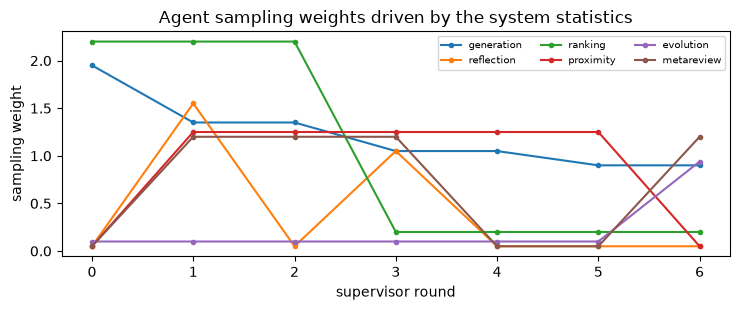

tasks completed: 34 | still queued: 2
dry-run population: 9 hypotheses, 36 synthetic matches


In [7]:
W = df([r["weights"] for r in log])
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for c in W.columns:
    ax.plot(W.index, W[c], marker="o", ms=3, label=c)
ax.set(xlabel="supervisor round", ylabel="sampling weight", title="Agent sampling weights driven by the system statistics")
ax.legend(fontsize=7, ncol=3); plt.tight_layout(); plt.show()
print("tasks completed:", len(dry.queue.completed), "| still queued:", len(dry.queue))
print("dry-run population:", len(dry_mem.hypotheses), "hypotheses,", len(dry_mem.matches), "synthetic matches")

## 2 · Generation agent (Methods "Generation agent"; Supp. Note 9.1)

> "The Generation agent employs a diverse array of strategies (encoded as prompts), techniques and tools to generate novel hypotheses, such as the following: **Literature exploration via web search** … **Simulated scientific debates** … **Iterative assumptions identification** … **Research expansion**."

All four run below. Everything from here on writes into one persistent `Memory` — the paper's
*context memory* — which the later sections keep extending.

In [8]:
MEM = Memory(OUT / "run", PLAN)
N_LIT = 1 if QUICK else 2

### 2a · Literature exploration via web search

The agent first decides *what* to search for, retrieves articles, and then runs the paper's
"hypothesis generation after literature review" prompt with the retrieved abstracts in the
`{articles_with_reasoning}` slot.

In [9]:
print(gen.LITERATURE_PROMPT)

You are an expert tasked with formulating a novel and robust hypothesis to address the following objective.

Describe the proposed hypothesis in detail, including specific entities, mechanisms, and anticipated outcomes.

This description is intended for an audience of domain experts.

You have conducted a thorough review of relevant literature and developed a logical framework for addressing the objective. The articles consulted, along with your analytical reasoning, are provided below.

Goal: {goal}

Criteria for a strong hypothesis:
{preferences}

Constraints:
{constraints}

Existing hypothesis (if applicable):
{source_hypothesis}

{instructions}{feedback}

Literature review and analytical rationale (chronologically ordered, beginning with the most recent analysis):

{articles_with_reasoning}

Proposed hypothesis (detailed description for domain experts):

{schema}


In [10]:
queries = gen.search_queries(PLAN, 3, MEM)
print("search queries chosen by the agent:")
for q in queries: print(" -", q)
ARTICLES = lit.search_many(queries, limit=3)
MEM.articles += [{"title": a.title, "year": a.year, "source": a.source} for a in ARTICLES]
if ARTICLES:
    display(df([{"title": a.title[:90], "year": a.year, "cites": a.citations, "abstract?": bool(a.abstract), "source": a.source} for a in ARTICLES]))
    print("sources used:", sorted({a.source for a in ARTICLES}))
else:
    print("!! literature retrieval unavailable (Semantic Scholar rate-limited AND OpenAlex unreachable);"
          " the agents below run UNGROUNDED and the notebook says so wherever that matters.")

search queries chosen by the agent:
 - data center cooling energy reduction waste heat reuse absorption chiller PUE
 - liquid cooling direct-to-chip rear door heat exchanger data center energy savings 27C inlet
 - machine learning model predictive control data center cooling optimization PUE server inlet temperature


,title,year,cites,abstract?,source
0,Future views on waste heat utilization – Case ...,2017,233,True,openalex
1,Utilizing data center waste heat in district h...,2017,247,True,openalex
2,Cooling Systems in Data Centers: State of Art ...,2015,237,True,openalex
3,DATA CENTERS IN THE AGE OF AI: A TUTORIAL SURV...,2025,1,True,openalex
4,Transforming Cooling Optimization for Green Da...,2017,37,True,openalex
5,SciNet: Lessons Learned from Building a Power-...,2010,516,True,openalex
6,Optimization Control Strategies and Evaluation...,2024,32,True,openalex


sources used: ['openalex']


In [11]:
from concurrent.futures import ThreadPoolExecutor
chunks = [ARTICLES[i::N_LIT] for i in range(N_LIT)] if ARTICLES else [[] for _ in range(N_LIT)]
with ThreadPoolExecutor(max_workers=N_LIT) as ex:
    lit_hyps = list(ex.map(lambda a: gen.from_literature(MEM, PLAN, a[:4]), chunks))
for h in lit_hyps:
    md(h.render(700))

### H02 · Optimized Cooling via Reinforcement Learning with Thermal Storage
*strategy:* `literature` · *category:* AI-driven cooling control with thermal energy storage · *round:* 0

**Summary.** This hypothesis proposes deploying a deep reinforcement learning (DRL) controller to dynamically manage a data center's cooling system in conjunction with a thermal energy storage (TES) unit, leveraging time-of-use electricity pricing and transient thermal inertia. The controller optimizes cooling energy consumption and PUE while strictly maintaining server inlet temperatures at or below 27°C.

**Hypothesis.** Integrating a deep reinforcement learning (DRL) agent that controls a chilled water storage tank (TES) and variable-speed cooling equipment can reduce cooling energy consumption and PUE by 15-25% compared to conventional rule-based controls, without exceeding a 27°C server inlet temperature limit. The DRL agent learns optimal policies to precool the TES during off-peak hours and discharge it during peak demand, while adjusting air handler fan speeds and chilled water setpoints in response to real-time IT load, weather, and electricity prices. This approach exploits the thermal capacitance of the building and IT equipment to shift cooling load and minimize energy costs, while maintaining ther …

**Rationale and specificity.** Conventional cooling controls are reactive and often over-provision cooling to avoid hot spots, leading to excessive energy use. Prior work shows that DRL can outperform traditional methods by learning from historical data and adapting to changing conditions (e.g., Li et al., 2017). However, most DRL approaches focus on direct equipment control without considering thermal storage. Adding TES provides a buffer that allows the DRL agent to decouple cooling generation from instantaneous demand, enabling load shifting and reducing chiller cycling. The 27°C inlet limit is a hard constraint that the DRL agent must satisfy, and the use of a safe reinforcement learning framework can ensure constrain …

**Experimental design and validation.** To validate, a simulation environment of a representative data center (e.g., with 100 racks, air-cooled servers, and a chilled water cooling plant) will be developed using physics-based models calibrated with real operational data. The DRL controller (e.g., DDPG with safety layer) will be trained and compared against a baseline rule-based controller (e.g., setpoint-based with chiller staging) under various scenarios: different IT loads, outdoor temperatures, and time-of-use electricity tariffs. Measurable quantities include: average PUE, cooling energy consumption (kWh), total electricity cost, and the maximum server inlet temperature (to verify it never exceeds 27°C). The acceptance criteri …

**Assumptions.** The data center's cooling system has sufficient thermal inertia (building mass, air volume) and a TES unit that can store a meaningful amount of cooling capacity (e.g., >10% of peak hourly cooling demand).; Accurate real-time monitoring of IT load, server inlet temperatures, and weather conditions is available for the DRL agent's observations.; The DRL algorithm can be trained in a safe manner (e.g., via offline training on historical data or with a safety shield) to avoid violating the 27°C inlet temperature constraint.; Time-of-use electricity pricing or demand charges are present, providing sufficient economic incentive for load shifting to offset the capital cost of TES and DRL implementation.; The cooling plant includes variable-speed chillers and pumps, allowing the DRL agent to modulate capacity efficiently.; Server inlet temperatures are representative of thermal conditions and can be maintained within limits through airflow management adjustments.


### H01 · Adaptive Cold-Aisle Containment with Predictive Airflow Modulation
*strategy:* `literature` · *category:* airflow management · *round:* 0

**Summary.** Dynamically adjusting cold-aisle containment airflow using real-time server load and temperature predictions can maintain inlet temperatures below 27°C while reducing total cooling energy and PUE. The hypothesis integrates existing containment infrastructure with machine-learning-based control of variable-frequency fans and cooling units.

**Hypothesis.** Implementing a predictive, adaptive cold-aisle containment system that modulates airflow from computer room air handlers (CRAHs) based on short-term forecasts of server power draw and thermal dynamics will maintain server inlet temperatures ≤27°C while reducing cooling energy by 15–25% and improving PUE by 0.05–0.10 compared to static containment with fixed setpoints. The system uses a neural-network model trained on historical sensor data (server power, temperatures, fan speeds) to predict inlet temperature 5–10 minutes ahead, then adjusts CRAH fan speeds and supply temperatures via a model-predictive controller to minimize cooling power while respecting the 27°C constraint.

**Rationale and specificity.** Static containment often overcools to handle worst-case loads, wasting energy. Predictive control exploits thermal inertia and load variability, especially in AI/HPC clusters with fluctuating utilization. This approach is non-obvious because it requires tight integration of real-time telemetry and control loops not common in legacy data centers, and it directly addresses the 27°C limit by proactively preventing excursions rather than reacting to them.

**Experimental design and validation.** Deploy in one test row of 20 servers with existing cold-aisle containment. Install sensors for inlet temperature, server power, and CRAH fan speed. Train a neural network on 2 weeks of data under static control. Then run 1 week of adaptive control vs. 1 week of static control (baseline). Measurable quantities: average server inlet temperature, maximum inlet temperature, total cooling energy (kWh), PUE. Acceptance criterion: adaptive control achieves ≤27°C max inlet temperature and reduces cooling energy by ≥15% relative to baseline.

**Assumptions.** Server inlet temperatures respond predictably to changes in CRAH airflow and supply temperature within a 5–10 minute horizon.; Historical sensor data is sufficient to train a model that generalizes to unseen load patterns.; The neural-network model can be executed in real-time on existing data center management hardware without excessive latency.; CRAH fans and chillers can modulate smoothly without mechanical wear or stability issues.; The test row's thermal environment is representative of other rows in the data center.; No server-level failures or maintenance events during the experiment that skew results.


### 2b · Simulated scientific debate (self-play)

> "the Generation agent simulates scientific debates among experts by employing self-critique and self-play techniques. These debates typically involve multiple turns of conversations leading to a refined hypothesis generated at the end."

The paper's prompt is a *single* expert prompt applied repeatedly: each turn sees the transcript so
far and either continues the discussion or terminates by writing `HYPOTHESIS` followed by the
finalised idea. One turn = one model call; the same model plays every expert.

In [12]:
DEBATE_TURNS = 3 if QUICK else 4
t0 = time.time()
debate_h, debate_turns_text = gen.simulated_debate(MEM, PLAN, max_turns=DEBATE_TURNS, verbose=True)
print(f"{len(debate_turns_text)} turns in {time.time()-t0:.0f}s")
display(df([{"turn": i + 1, "chars": len(t), "declares HYPOTHESIS": "HYPOTHESIS" in t,
             "opening": t.strip().replace(chr(10), " ")[:110]} for i, t in enumerate(debate_turns_text)]))
md("**Turn 1 (the three opening proposals the paper's prompt asks for), abridged:**\n\n> "
   + debate_turns_text[0][:1100].replace(chr(10), "\n> "))
md(debate_h.render(700))

  debate turn 1: 3847 chars


  debate turn 2: 6183 chars


  debate turn 3: 5653 chars


  debate turn 4: 5583 chars


4 turns in 105s


,turn,chars,declares HYPOTHESIS,opening
0,1,3847,False,"As the initiator, I'll propose three distinct ..."
1,2,6183,False,Excellent initiation. These three hypotheses c...
2,3,5653,False,Excellent and rigorous evaluation. You have co...
3,4,5583,False,--- turn 4 --- Your refinement is a significa...


**Turn 1 (the three opening proposals the paper's prompt asks for), abridged:**

> As the initiator, I'll propose three distinct hypotheses for optimizing data center cooling while keeping server inlet temperatures ≤27°C. These target practical, deployable solutions balancing energy efficiency, cost, and scalability.
> 
> ---
> 
> ### Hypothesis 1: Adaptive Aisle Containment with Dynamic Airflow Tuning
> **Idea:** Retrofit existing hot/cold aisle containment with motorized, sensor-controlled dampers and variable-speed fans at each server rack's perforated tile or rear door. A centralized AI controller uses real-time inlet temperature sensors (every 3-5 racks) and server utilization telemetry to dynamically adjust damper openings and local fan speeds, maintaining ≤27°C while reducing total cooling airflow by 15–25%.  
> - **Novelty:** Moves beyond static containment or blanket CRAC adjustments to granular, per-rack airflow modulation.  
> - **Feasibility:** Low-cost hardware (dampers, small fans, IoT sensors); software layer can be integrated with existing DCIM or BMS systems.  
> - **Impact:** Directly reduces fan and chiller energy (PUE improvement ~0.05–0.10).  
> - **Limitations:

### H03 · Predictive Feed-Forward CRAC with Reconfigurable Airflow Guidance
*strategy:* `debate` · *category:* hybrid predictive cooling control · *round:* 0

**Summary.** This hypothesis combines a periodically reconfigurable passive airflow system with a hybrid feed-forward and feedback CRAC controller. The controller uses short-term workload forecasts to proactively adjust cooling, smoothing thermal transients and enabling tighter operation near the 27°C limit, thereby reducing PUE without violating the temperature constraint.

**Hypothesis.** Implementing a three-layer system—(1) manually adjustable baffles/blanking panels reconfigured during maintenance, (2) a CRAC controller that combines feedback from sparse inlet sensors with feed-forward from a workload forecast (e.g., from job scheduler or time-series model), and (3) a periodic DCIM-based optimizer for baffle configuration—will reduce total cooling power while maintaining all server inlet temperatures ≤27°C, achieving a PUE improvement of 0.06–0.12 over a purely reactive sparse-sensor controller.

**Rationale and specificity.** Purely reactive controllers must maintain conservative safety margins to avoid transient violations, wasting energy. A workload-derived feed-forward signal anticipates thermal spikes, allowing pre-cooling that reduces overshoot and enables operation closer to the 27°C limit. This is novel because it integrates a simple, low-overhead predictive element into a sparse-sensor feedback loop, avoiding the complexity of full workload scheduling while addressing a key gap in prior static-tile or reactive-only designs.

**Experimental design and validation.** Deploy the system in a test data center zone with 20 racks, 2 CRAC units, and sparse inlet sensors. Compare three controllers over one week each: (A) baseline reactive sparse-sensor, (B) reactive + reconfigurable baffles (periodic optimization), (C) hybrid feed-forward + feedback + reconfigurable baffles. Measure total cooling power (kW), maximum inlet temperature (°C), and PUE. Acceptance criterion: System (C) achieves ≥8% cooling energy reduction relative to (A) with zero violations of the 27°C limit.

**Assumptions.** Short-term workload forecasts (e.g., 5–15 minute horizon) are available from the job scheduler or a time-series model with sufficient accuracy to predict thermal transients.; The sparse sensor network combined with a simplified thermal model provides a reliable real-time estimate of the hottest server inlet temperature.; The prescriptive analytics tool can compute an optimal baffle configuration that remains effective until the next maintenance window (e.g., weekly).; The feed-forward pre-cooling margin (0.5–1°C) does not cause excessive overcooling or energy waste when forecasts are inaccurate.; Manually reconfiguring baffles during maintenance windows is operationally feasible and does not introduce significant labor costs.; The system can be tuned to avoid instability from the interaction between feed-forward and feedback loops.


### 2c · Iterative assumptions identification

> "The agent iteratively identifies testable intermediate assumptions, which, if proven true, can lead to novel scientific discovery. These plausible assumptions and their sub-assumptions are identified through **conditional reasoning hops** and subsequently aggregated into complete hypotheses."

Each hop takes the previous hop's assumptions and goes one level deeper; the chain is then
aggregated into one hypothesis.

In [13]:
HOPS = 1 if QUICK else 2
chain = gen.assumption_hops(PLAN, MEM, hops=HOPS, n=3)
display(df([{"hop": a.get("hop"), "assumption": a["assumption"][:95],
             "if true then": str(a.get("if_true_then", ""))[:85],
             "sub-assumption": str(a.get("sub_assumption", ""))[:85]} for a in chain]))
assum_h = gen.from_assumptions(MEM, PLAN, chain)
md(assum_h.render(700))

,hop,assumption,if true then,sub-assumption
0,1,Raising the supply air temperature from typica...,Existing cooling systems can operate with sign...,A dynamic control algorithm that adjusts suppl...
1,1,Containment of cold aisles (fully enclosed wit...,A retrofit of cold aisle containment in existi...,The marginal benefit of containment on inlet t...
2,1,Using a liquid-cooled rear-door heat exchanger...,A hybrid cooling architecture (RDHx for hot sp...,RDHx units can operate with water temperatures...
3,2,A dynamic control algorithm that adjusts suppl...,It becomes plausible that supply air temperatu...,The algorithm can predict server intake temper...
4,2,The marginal benefit of containment on inlet t...,It becomes plausible that deploying cold-aisle...,"In high-density racks, the reduction in inlet ..."
5,2,RDHx units can operate with water temperatures...,It becomes plausible that RDHx can be integrat...,The heat removal capacity of a typical RDHx at...


### H04 · Hybrid Cooling with Dynamic Control and Containment
*strategy:* `assumptions` · *category:* hybrid cooling · *round:* 0

**Summary.** This hypothesis proposes a hybrid cooling architecture that combines cold-aisle containment for high-density racks, liquid-cooled rear-door heat exchangers (RDHx) for hot spots, and a dynamic control algorithm that adjusts supply air temperature in real time. The goal is to reduce cooling energy and PUE while keeping all server inlet temperatures ≤27°C.

**Hypothesis.** In a data center with mixed rack densities, deploying cold-aisle containment on high-density racks (>10 kW/rack) and retrofitting those same racks with RDHx units operating at 40°C water inlet temperature, while using a dynamic control algorithm to raise supply air temperature to 26-27°C for the rest of the facility, will reduce total cooling energy by 25-35% and improve PUE by 0.15-0.25 compared to a baseline fully air-cooled design with supply air at 22°C, without any server inlet exceeding 27°C.

**Rationale and specificity.** The mechanism is specific because it targets the most problematic high-density racks where recirculation forces lower supply temperatures. Containment reduces recirculation and temperature variance, RDHx removes most heat from those racks at high water temperatures enabling free cooling, and the dynamic control algorithm safely raises supply temperature for the rest of the data center. This combination is non-obvious because it leverages the synergy between containment and RDHx on high-density racks to unlock aggressive supply temperature increases elsewhere, maximizing savings while respecting the 27°C limit.

**Experimental design and validation.** Deploy the hybrid system in a test data center with at least 10 high-density racks (>10 kW/rack) and 20 low-density racks. Measure baseline PUE, total cooling energy, and server inlet temperatures for one month with conventional cooling (supply air 22°C, no containment, no RDHx). Then implement: (a) cold-aisle containment on high-density racks, (b) RDHx units on those racks with 40°C water, (c) dynamic control algorithm raising supply air to 26-27°C for the rest. Measure the same metrics for one month. Acceptance criterion: total cooling energy reduction ≥25%, PUE improvement ≥0.15, and no server inlet temperature exceeds 27°C at any time.

**Assumptions.** Raising supply air temperature to 26-27°C for low-density racks does not cause any server inlet to exceed 27°C when combined with dynamic control.; Cold-aisle containment on high-density racks reduces inlet temperature variance by at least 3°C (95th percentile vs median).; RDHx units operating with 40°C water inlet temperature remove at least 80% of the server heat load from high-density racks.; The dynamic control algorithm can predict server intake temperatures within ±0.5°C using sparse sensors and a low-order thermal model.; The hybrid system's total fan and pump energy increase is less than 10% of the cooling energy savings.


### 2d · Research expansion

> "To identify previously unexplored areas of the hypothesis space, the Generation agent reviews existing hypotheses and the research overview and feedback provided by the Meta-review agent in the previous iteration."

This is the first iteration, so there is no meta-review yet and the agent expands only against the
existing hypotheses; §7 shows the same call with the meta-review critique attached, and §8 runs it
inside the loop where the feedback is always present.

In [14]:
exp_h, unexplored = gen.research_expansion(MEM, PLAN)
md("**Areas the agent judged unexplored by the current population:**\n" + "\n".join(f"- {u}" for u in unexplored))
md(exp_h.render(700))

**Areas the agent judged unexplored by the current population:**
- Waste heat driven absorption cooling with non-condensing control
- Electrochromic/tunable-emittance building envelope integration
- Novel free-air-side heat exchanger with passive thermal mass buffering

### H05 · Waste-heat-driven absorption chiller for server inlet tempering
*strategy:* `expansion` · *category:* waste heat recovery and absorption cooling · *round:* 0

**Summary.** Absorption chillers can use data center waste heat to pre-cool supply air, reducing compressor work. By deliberately operating server outlets at 45–50°C, the absorption cycle can be driven efficiently, while a trim cooler ensures inlet temperatures stay ≤27°C. This decouples cooling from electrical chiller load, cutting PUE.

**Hypothesis.** Integrating a single-effect LiBr-H2O absorption chiller that reclaims heat from server exhaust to pre-cool CRAH return water (from 27°C to 18°C) before the vapour-compression chiller will reduce total cooling energy by ≥18% without raising any rack inlet above 27°C, compared to a conventional chilled water system with cold-aisle containment.

**Rationale and specificity.** Conventional waste heat reuse (e.g., district heating) demands high outlet temperatures (~60°C) to be valuable, but most data centers operate at 35–40°C exhaust. Absorption chillers can be driven by lower-grade heat (70–90°C generator), which can be achieved in a hot-aisle containment setup with modest temperature boosting via a small heat pump. The pre-cooling effect reduces compressor lift and energy. This approach is non-obvious because it shifts from 'reject waste heat' to 'exploit waste heat for cooling', and avoids the complexity of chemical/desiccant systems.

**Experimental design and validation.** In a lab-scale data center module (6 racks, 2 CRAHs, total 50 kW IT load), install a 20 kW single-effect LiBr absorption chiller. Configure hot-aisle containment to capture exhaust at 48°C ± 2°C; use a plate heat exchanger to transfer heat to a 90°C hot water loop for the generator. The absorption chiller cools a 27°C return water stream to 18°C, reducing the vapour-compression chiller's lift. Measure: chiller electric power (kW), absorption input heat (kW), IT power, server inlet temperatures. Compare to baseline (same layout, conventional chiller only). Acceptance criterion: cooling energy (kWh) reduction ≥ 18% while maximum any server inlet temperature ≤ 27°C.

**Assumptions.** Server exhaust temperature of 48°C is achievable without exceeding component limits.; A small heat pump can boost exhaust heat to 90°C with COP > 3.0.; LiBr-H2O absorption chiller COP is ≥ 0.7 at 90°C/40°C/7°C generator/condenser/evaporator conditions.; The absorption chiller capacity (20 kW) is sufficient to pre-cool 30% of the return water flow.; No significant fouling or condensation issues occur in the exhaust-to-water heat exchanger.; The trim chiller can handle the remaining cooling load while maintaining inlet temperatures ≤27°C.


In [15]:
md("**Population after the Generation agent** (the paper's Generation agent \"also summarizes and categorizes each generated hypothesis\"):")
display(df([{"id": h.hid, "strategy": h.strategy, "category": h.category, "title": h.title,
             "assumptions": len(h.assumptions)} for h in MEM.active()]).set_index("id"))

**Population after the Generation agent** (the paper's Generation agent "also summarizes and categorizes each generated hypothesis"):

,strategy,category,title,assumptions
id,,,,
H01,literature,airflow management,Adaptive Cold-Aisle Containment with Predictiv...,6
H02,literature,AI-driven cooling control with thermal energy ...,Optimized Cooling via Reinforcement Learning w...,6
H03,debate,hybrid predictive cooling control,Predictive Feed-Forward CRAC with Reconfigurab...,6
H04,assumptions,hybrid cooling,Hybrid Cooling with Dynamic Control and Contai...,5
H05,expansion,waste heat recovery and absorption cooling,Waste-heat-driven absorption chiller for serve...,6


## 3 · Reflection agent (Methods "Reflection agent"; Supp. Note 9.2, 10.3–10.8)

> "The Reflection agent … simulates the role of a scientific peer reviewer, critically examining the correctness, quality, and novelty of the generated hypotheses. … Effective reviews **filter** inaccurate and, when stipulated, non-novel hypotheses."

Six review strategies, all run below.

**One deviation.** In the paper the model decides whether to discard a hypothesis. Here the model's
recommendation is recorded but the *filter itself* is a deterministic threshold rule over the
reviewer's own scores (`reflection.passes`), so the notebook can show exactly which hypotheses are
discarded and why.

In [16]:
show_source(ref.passes)
for scores in [{"correctness": 8, "quality": 9, "novelty": 7, "safety": 8},
               {"correctness": 3, "quality": 7, "novelty": 6, "safety": 9},
               {"correctness": 7, "quality": 6, "novelty": 2, "safety": 8},
               {"correctness": 7, "quality": 6, "novelty": 6, "safety": 4}]:
    print(scores, "→", ref.passes(scores))

**passes**

```python
def passes(scores: dict[str, float], thresholds: dict[str, float] | None = None) -> tuple[bool, str]:
    """Deterministic quick filter over the reviewer's scores. Returns (passed, reason)."""
    th = thresholds or INITIAL_THRESHOLDS
    bad = [f"{k}={scores.get(k, 0):.0f}<{v:.0f}" for k, v in th.items() if float(scores.get(k, 0)) < v]
    return (not bad), ("below threshold: " + ", ".join(bad) if bad else "all criteria above threshold")

```

{'correctness': 8, 'quality': 9, 'novelty': 7, 'safety': 8} → (True, 'all criteria above threshold')
{'correctness': 3, 'quality': 7, 'novelty': 6, 'safety': 9} → (False, 'below threshold: correctness=3<4')
{'correctness': 7, 'quality': 6, 'novelty': 2, 'safety': 8} → (False, 'below threshold: novelty=2<3')
{'correctness': 7, 'quality': 6, 'novelty': 6, 'safety': 4} → (False, 'below threshold: safety=4<5')


### 3a · Initial review — the quick, tool-free filter

In [17]:
print(ref.INITIAL_PROMPT[:900], "…")

You are performing an INITIAL REVIEW: a fast, tool-free triage whose purpose is to discard flawed, non-novel or unsuitable hypotheses before any expensive review.

Goal: {goal}

Evaluation criteria:
{preferences}

Constraints the output must satisfy:
{constraints}

Hypothesis:
{hypothesis}
{feedback}

Assess, using only your own knowledge (no external sources):
1. Correctness — is the mechanism physically/technically sound? Name any readily apparent flaw.
2. Quality — is it specific, detailed and testable, or vague?
3. Novelty — is this simply standard practice already deployed at scale, or does it propose something not routine?
4. Safety — could acting on it cause harm (equipment damage, thermal excursion, unsafe operation)?

Return JSON:
{{"correctness": 0-10, "quality": 0-10, "novelty": 0-10, "safety": 0-10,
  "critiques": ["specific, actionable critique", ...],
  "decision": "accept" …


In [18]:
NEW = list(MEM.active())
with ThreadPoolExecutor(max_workers=6) as ex:
    initials = list(ex.map(lambda h: ref.initial_review(h, PLAN, MEM), NEW))
for h, r in zip(NEW, initials):
    MEM.add_review(r)
    if r.decision == "reject":
        h.status, h.reject_reason = "rejected", r.text
display(df([{"id": h.hid, "strategy": h.strategy, **{k: r.scores[k] for k in ref.SCORE_KEYS},
             "model says": r.extra["model_decision"], "FILTER": r.decision,
             "why": r.extra["filter_reason"], "first critique": (r.critiques or [""])[0][:80]}
            for h, r in zip(NEW, initials)]).set_index("id"))
print("survivors:", [h.hid for h in MEM.active() if h.status != "rejected"],
      "| discarded:", [h.hid for h in MEM.hypotheses.values() if h.status == "rejected"])

,strategy,correctness,quality,novelty,safety,model says,FILTER,why,first critique
id,,,,,,,,,
H01,literature,7.0,8.0,3.0,7.0,reject,accept,all criteria above threshold,Predictive airflow modulation for cold-aisle c...
H02,literature,7.0,8.0,4.0,6.0,reject,accept,all criteria above threshold,The claimed 15-25% reduction in cooling energy...
H03,debate,7.0,8.0,6.0,7.0,accept,accept,all criteria above threshold,Feed-forward from workload forecast may not ca...
H04,assumptions,6.0,8.0,7.0,7.0,accept,accept,all criteria above threshold,RDHx units at 40°C water inlet may not provide...
H05,expansion,3.0,8.0,6.0,4.0,reject,reject,"below threshold: correctness=3<4, safety=4<5",The claimed 18% reduction is unsubstantiated: ...


survivors: ['H01', 'H02', 'H03', 'H04'] | discarded: ['H05']


### 3b · Full review with literature

> "If a hypothesis passes the initial review, the Reflection agent performs a full review, leveraging external tools and web searches … For novelty, it summarizes known aspects of the hypothesis and then judges their novelty based on existing literature."

Supplementary Note 10.3 shows exactly this shape: an *"aspects already explored"* list followed by
*"novel aspects"*.

In [19]:
SURV = [h for h in MEM.active()]
with ThreadPoolExecutor(max_workers=6) as ex:
    fulls = list(ex.map(lambda h: ref.full_review(h, PLAN, MEM), SURV))
for h, r in zip(SURV, fulls):
    MEM.add_review(r)
    h.status = "rejected" if r.decision == "reject" else "reviewed"
    if r.decision == "reject": h.reject_reason = r.text
display(df([{"id": h.hid, **{k: r.scores[k] for k in ref.SCORE_KEYS}, "FILTER": r.decision,
             "already explored": len(r.extra["already_explored"]), "novel aspects": len(r.extra["novel_aspects"]),
             "articles read": len(r.extra["articles"])} for h, r in zip(SURV, fulls)]).set_index("id"))
ex_r = fulls[0]
md(f"**Full review of {SURV[0].hid} — the novelty section, in the paper's format**\n\n"
   "*Aspects already explored:*\n" + "\n".join(f"- {a}" for a in ex_r.extra["already_explored"][:5])
   + "\n\n*Novel aspects:*\n" + "\n".join(f"- {a}" for a in ex_r.extra["novel_aspects"][:5])
   + "\n\n*Critiques:*\n" + "\n".join(f"- {c}" for c in ex_r.critiques[:4]))
print(json.dumps({"hid": ex_r.hid, "kind": ex_r.kind, "scores": ex_r.scores, "decision": ex_r.decision,
                  "articles": ex_r.extra["articles"]}, indent=1)[:900])

,correctness,quality,novelty,safety,FILTER,already explored,novel aspects,articles read
id,,,,,,,,
H01,6.0,5.0,5.0,7.0,accept,3,2,4
H02,7.0,6.0,6.0,6.0,accept,4,4,4
H03,6.0,7.0,7.0,8.0,accept,5,3,4
H04,2.0,3.0,4.0,5.0,reject,4,3,4


**Full review of H01 — the novelty section, in the paper's format**

*Aspects already explored:*
- Multi-objective optimization of ACS energy consumption and rack intake temperature using genetic algorithms (NSGA-II) with neural-network-based evaluation has been proposed for data centers.
- Dynamic cooling solutions that adapt to variations in IT power dissipation at module, server, and rack levels have been explored, including concepts of adaptive and energy-efficient cooling.
- The use of sensors and telemetry to monitor server inlet temperatures and CRAH fan speeds is standard practice in modern data centers.

*Novel aspects:*
- The specific combination of short-term (5–10 minute) predictive neural-network forecasting of inlet temperatures with model-predictive control to proactively modulate CRAH airflow and supply temperature, explicitly targeting a 27 °C inlet constraint, is not found in the retrieved literature.
- The explicit claim of achieving 15–25% cooling energy reduction and 0.05–0.10 PUE improvement beyond static containment, validated with a controlled experiment, appears to be a new quantitative target that is not directly reported in the retrieved papers.

*Critiques:*
- The hypothesis assumes that a neural network trained on only 2 weeks of static-control data will generalize to dynamic conditions and provide accurate 5–10 minute predictions; this is questionable without evidence of data diversity (e.g., different load patterns, seasonal variations).
- The model-predictive controller's optimization horizon, computational cost, and real-time feasibility in a legacy data center are not addressed; without this, deployability and scalability are uncertain.
- The acceptance criterion of ≥15% cooling reduction is not justified by the literature; the cited works do not report such high savings for predictive adaptive containment.
- The hypothesis does not account for CRAH supply air temperature limits or chiller-side interactions that may affect overall cooling power and PUE; cooling energy reduction may not directly translate to PUE improvement if chiller power increases.

{
 "hid": "H01",
 "kind": "full",
 "scores": {
  "correctness": 6.0,
  "quality": 5.0,
  "novelty": 5.0,
  "safety": 7.0
 },
 "decision": "accept",
 "articles": [
  "Multi-Objective Optimization of Energy Saving Control for Air Conditioning System in Data Center",
  "Minimizing Power Consumption At Module, Server And Rack-levels Within A Data Center Through Design And Energy-efficient Operation Of Dynamic Cooling Solutions",
  "Pollutant transport and dispersion in large indoor spaces: A status report for the large space effort of the Interiors Project",
  "Global Strategy for the Diagnosis, Management, and Prevention of Chronic Obstructive Pulmonary Disease"
 ]
}


### 3c · Deep verification review

> "decomposing the hypothesis into constituent assumptions. Each assumption is further broken down into fundamental sub-assumptions, **decontextualized**, and independently evaluated for correctness to identify invalidating elements … An identified error doesn't necessarily invalidate the core hypothesis; the Reflection agent assesses whether the incorrect assumption is **fundamental**."

Decompose (1 call) → probe every decontextualised sub-assumption independently (parallel calls) →
aggregate into a verdict that separates fundamental from non-fundamental errors.

In [20]:
DV_TARGETS = [h for h in MEM.active()][: (1 if QUICK else 2)]
with ThreadPoolExecutor(max_workers=2) as ex:
    dvs = list(ex.map(lambda h: ref.deep_verification(h, PLAN, MEM, n_assumptions=2 if QUICK else 3), DV_TARGETS))
for h, (r, probes) in zip(DV_TARGETS, dvs):
    MEM.add_review(r)
    md(f"**Deep verification of `{h.hid}` — {h.title}** · decision **{r.decision}** · scores {r.scores}")
    display(df([{"assumption": p["assumption"][:60], "fundamental": p["fundamental"],
                 "decontextualised sub-assumption": p["sub_assumption"][:85],
                 "verdict": p["verdict"], "conf": round(p["confidence"], 2)} for p in probes]))
    md("*Invalidating elements:* " + ("; ".join(r.critiques) or "none") +
       "\n\n*Non-fundamental errors (can be fixed later by the Evolution agent):* "
       + ("; ".join(map(str, r.extra["non_fundamental_errors"])) or "none"))

**Deep verification of `H01` — Adaptive Cold-Aisle Containment with Predictive Airflow Modulation** · decision **reject** · scores {'correctness': 3.0, 'quality': 5.0, 'novelty': 7.0, 'safety': 2.0}

,assumption,fundamental,decontextualised sub-assumption,verdict,conf
0,The neural-network model can accurately predic...,True,"Historical sensor data (server power, temperat...",correct,0.90
1,The neural-network model can accurately predic...,True,The neural-network model generalizes from trai...,partially correct,0.85
2,The neural-network model can accurately predic...,True,The 5–10 minute prediction horizon is long eno...,partially correct,0.85
3,The model-predictive controller can reduce coo...,True,The controller can modulate CRAH fan speeds an...,incorrect,0.85
4,The model-predictive controller can reduce coo...,True,The expected energy savings are achievable giv...,unknown,0.30
5,The model-predictive controller can reduce coo...,True,The controller's actions do not cause unintend...,incorrect,0.95
6,The experimental setup (one test row of 20 ser...,False,The test row's thermal dynamics and load patte...,partially correct,0.70
7,The experimental setup (one test row of 20 ser...,False,Two weeks of training data capture the full ra...,incorrect,0.95
8,The experimental setup (one test row of 20 ser...,False,The one-week comparison period is long enough ...,incorrect,0.90


*Invalidating elements:* The controller cannot modulate CRAH fan speeds and supply temperatures quickly enough to stay within the 27°C limit during load transients due to CRAH thermal inertia.; The controller's actions are likely to cause unintended negative effects (hot spots, condensation) that offset energy gains.; Two weeks of training data are insufficient to capture the full range of operating conditions (seasonal, load, failure modes) needed for model robustness.; A one-week comparison period is too short to observe statistically significant differences in cooling energy and PUE, given typical variability and small effect sizes.

*Non-fundamental errors (can be fixed later by the Evolution agent):* The neural-network model may not generalize to unseen operating conditions without retraining or transfer learning.; The test row's thermal dynamics and load patterns may not fully represent a full-scale data center, limiting extrapolation.; The 5–10 minute prediction horizon may be insufficient for large thermal masses or phase-change cooling systems.

**Deep verification of `H02` — Optimized Cooling via Reinforcement Learning with Thermal Storage** · decision **reject** · scores {'correctness': 5.0, 'quality': 7.0, 'novelty': 8.0, 'safety': 3.0}

,assumption,fundamental,decontextualised sub-assumption,verdict,conf
0,A deep reinforcement learning agent can learn ...,True,A reinforcement learning algorithm exists that...,correct,0.95
1,A deep reinforcement learning agent can learn ...,True,The learned policy can maintain server inlet t...,unknown,0.30
2,A deep reinforcement learning agent can learn ...,True,The DRL agent can effectively handle the joint...,correct,0.85
3,Integrating a chilled water thermal storage ta...,False,Precooling the TES during off-peak hours and d...,partially correct,0.95
4,Integrating a chilled water thermal storage ta...,False,The thermal capacitance of the building and IT...,partially correct,0.60
5,Integrating a chilled water thermal storage ta...,False,The combined DRL+TES system can reduce chiller...,correct,0.90
6,The simulation environment and pilot test bed ...,True,Physics-based models calibrated with real oper...,correct,0.90
7,The simulation environment and pilot test bed ...,True,The pilot deployment on a small test bed will ...,incorrect,0.85
8,The simulation environment and pilot test bed ...,True,"Real-world disturbances (e.g., sensor noise, a...",incorrect,0.90


*Invalidating elements:* The claim that the learned policy can maintain server inlet temperature at or below 27°C for 99.9% of time steps is unsupported and lacks empirical evidence, making it a high-risk assumption.; The hypothesis implies that precooling TES reduces total cooling energy, but it actually increases energy slightly; the benefit is cost savings, not energy reduction, which undermines the claimed 15-25% energy reduction.; The thermal capacitance of the building and IT equipment may be insufficient for meaningful load shifting without violating the 27°C limit, especially in high-density data centers.; Real-world disturbances (sensor noise, actuator delays, unmodeled dynamics) are likely to degrade DRL performance below the acceptance criterion, as confirmed by probe results.

*Non-fundamental errors (can be fixed later by the Evolution agent):* The pilot deployment may not perfectly reproduce simulation results, but this can be addressed through iterative calibration and robust design.; The DRL agent's ability to handle joint control of multiple components is well-supported, though training and generalization depend on simulation fidelity, which can be improved.

### 3d · Observation review (prompt reproduced from Supp. Note 9.2)

> "the Reflection agent also explores whether a given hypothesis can account for long-tail observations from prior experimental results. … the agent assesses if the hypothesis is a superior explanation over existing ones."

The prompt's terminal line classifies the hypothesis against one article's observations as
*already explained / other explanations more likely / missing piece / neutral / disproved*. The
paper notes this review "often completes without any important findings".

In [21]:
print(ref.OBSERVATION_PROMPT[:750], "…")

You are an expert in scientific hypothesis evaluation. Your task is to analyze the relationship between a provided hypothesis and observations from a scientific article. Specifically, determine if the hypothesis provides a novel causal explanation for the observations, or if they contradict it.

Instructions:

1. Observation extraction: list relevant observations from the article.
2. Causal analysis (individual): for each observation:
   a. State if its cause is already established.
   b. Assess if the hypothesis could be a causal factor (hypothesis => observation). Start with: "would we see this observation if the hypothesis was true:".
   c. Explain if it's a novel explanation. If not, or if a better explanation exists, state: "not a miss …


In [22]:
obs_arts = ARTICLES[:2] if ARTICLES else []
if obs_arts:
    targets = [h for h in MEM.active()][:len(obs_arts)]
    with ThreadPoolExecutor(max_workers=2) as ex:
        obs = list(ex.map(lambda p: ref.observation_review(p[0], PLAN, MEM, p[1]), list(zip(targets, obs_arts))))
    for r in obs: MEM.add_review(r)
    display(df([{"hypothesis": r.hid, "article": r.extra["article"][:70], "verdict": r.extra["verdict"]} for r in obs]))
    md("**Excerpt of the observation review reasoning:**\n\n> " + obs[0].text[-1200:].replace(chr(10), "\n> "))
else:
    print("skipped: no articles retrieved (literature APIs unavailable)")

,hypothesis,article,verdict
0,H01,Future views on waste heat utilization – Case ...,neutral
1,H02,Utilizing data center waste heat in district h...,neutral


**Excerpt of the observation review reasoning:**

> usal analysis (summary):**  
> Would we see some of the observations if the hypothesis was true: The observations primarily concern waste heat *utilization* barriers and economics. The hypothesis is about improving *cooling efficiency* inside the data center, not about enabling or enhancing waste heat recovery. While reduced cooling energy could slightly increase waste heat temperature (by reducing overcooling), that effect is minor and not directly linked to overcoming low-temperature or instability barriers. The observations are largely independent of the hypothesis’s proposed mechanism.  
> 
> **Disproof analysis:**  
> Do some observations disprove the hypothesis: No. The observations do not contradict the hypothesis. The hypothesis can be true (reducing cooling energy by 15–25%) even if waste heat utilization barriers persist. The article’s findings about low waste heat quality and high investment costs are contextual but not contradictory.  
> 
> **Conclusion:** The hypothesis neither explains the observations nor is contradicted by them. It addresses a different aspect of data center operation (cooling energy) than the article’s focus (waste heat utilization).  
> 
> **hypothesis: neutral**

### 3e · Simulation review

> "The Reflection agent also reviews hypotheses by **simulating them in a step-wise fashion** (e.g., simulating the mechanism of action or the proposed experiment) … This review method is built on the assumption that frontier LLMs may have developed an internal world model of science."

In [23]:
SIM_TARGETS = [h for h in MEM.active()][: (1 if QUICK else 2)]
with ThreadPoolExecutor(max_workers=2) as ex:
    sims = list(ex.map(lambda h: ref.simulation_review(h, PLAN, MEM), SIM_TARGETS))
for h, r in zip(SIM_TARGETS, sims):
    MEM.add_review(r)
    md(f"**Simulation review of `{h.hid}`** · decision **{r.decision}** · scores {r.scores}")
    display(df([{"step": s.get("step", "")[:70], "state": str(s.get("state", ""))[:70], "risk": str(s.get("risk", ""))[:70]} for s in r.extra["steps"]]))
    md("*Failure scenarios:* " + "; ".join(r.critiques[:4]))

**Simulation review of `H01`** · decision **reject** · scores {'correctness': 6.0, 'quality': 7.0, 'novelty': 6.0, 'safety': 5.0}

,step,state,risk
0,"Training Phase: Install sensors, collect 2 wee...",Sensor data captured at 1-minute intervals. Va...,Sensor drift or noise; missing transient event...
1,Train a neural network on historical data to p...,"Model learns mapping [P(t-1..t-k), RPM(t-1..t-...",Overfitting to training period (low variabilit...
2,Implement model-predictive controller (MPC) th...,MPC solves: min sum(P_cooling(t+k)) s.t. predi...,MPC horizon too short to anticipate rapid load...
3,Switch to adaptive control for 1 week. CRAH fa...,"Under adaptive control: at low loads, fans slo...","If prediction is late (e.g., load spike within..."
4,Compare measured outcomes: average and max inl...,Expected result: adaptive control yields max i...,Baseline static control already optimized (e.g...


*Failure scenarios:* Load spikes occur faster than the 5-min prediction horizon (e.g., burst-parallel job launches), causing inlet temp >27°C.; NN model trained on 2-week historical data fails to generalize to different workload mixes (e.g., AI training vs. web serving) leading to poor predictions.; MPC assumes linear dynamics but actual thermal response is nonlinear (e.g., recirculation hot spots), so optimized control violates constraints.; Sensor accuracy degrades (e.g., thermistors drift by 0.5°C), causing false constraint satisfaction or violation.

**Simulation review of `H02`** · decision **reject** · scores {'correctness': 7.0, 'quality': 7.0, 'novelty': 6.0, 'safety': 6.0}

,step,state,risk
0,The data center operates with a baseline rule-...,Steady-state operation with no TES discharge. ...,"Baseline is over-provisioning cooling, but not..."
1,"The DRL agent observes state: IT load, outdoor...","TES temperature drops from 6°C to 4°C, storing...",Precooling may cause overcooling and increase ...
2,"During peak hours (price $0.20/kWh), the DRL a...","Chiller power drops to 200 kW, fan power incre...","If TES is discharged too quickly, inlet temper..."
3,The DRL agent adjusts chilled water setpoint f...,"Chiller power drops to 150 kW, fan power to 40...",Raising setpoint too high may cause hot spots ...
4,The DRL agent is trained in a simulated enviro...,Simulation environment produces realistic dyna...,Simulation model may not capture all real-worl...
5,The DRL controller is deployed on a small test...,Test bed shows a 12% reduction in cooling ener...,Real-world deployment reveals model mismatch a...


*Failure scenarios:* TES capacity is insufficient to shift peak load, leading to chiller operation during peak and higher costs.; DRL agent exploits simulation inaccuracies, causing inlet temperatures to exceed 27°C in real operation.; Safety layer is too conservative, preventing the agent from achieving the 15% reduction.; Chiller efficiency degrades at low load, negating energy savings from TES discharge.

### 3f · Recurrent / tournament review

> "The Reflection agent adapts its full reviews based on Co-Scientist's growing knowledge. By analyzing reviewed hypotheses and results of the tournament conducted by the Ranking agent, the Reflection agent identifies recurring issues and improvement opportunities, refining its reviews accordingly."

This review consumes the Meta-review critique, so we first synthesise a *bootstrap* critique from
the reviews produced so far (§7 repeats it with the tournament debate transcripts included) and
then run one tournament review against it.

In [24]:
boot = meta.synthesize(MEM, PLAN)
print("bootstrap meta-review critique — recurring patterns:")
display(df([{"pattern": c.get("pattern"), "count": c.get("count"), "guidance": str(c.get("guidance"))[:100]}
            for c in boot["recurring_critiques"]]))
tr_target = MEM.active()[0]
tr = ref.tournament_review(tr_target, PLAN, MEM); MEM.add_review(tr)
md(f"**Tournament review of `{tr_target.hid}`** (no matches played yet — the win/loss field is empty by construction)\n\n"
   f"- *recurring issues this hypothesis exhibits:* {'; '.join(map(str, tr.extra['recurring_issues_present'])) or 'none'}\n"
   f"- *improvement opportunities:* {'; '.join(tr.critiques[:4])}\n"
   f"- *decision:* {tr.decision} · scores {tr.scores}")
print("reviews in context memory:", {k: sum(1 for r in MEM.reviews if r.kind == k) for k in sorted({r.kind for r in MEM.reviews})})

bootstrap meta-review critique — recurring patterns:


,pattern,count,guidance
0,Overclaimed energy/PUE savings,8,Future hypotheses must justify savings targets...
1,Insufficient safety margin for 27°C limit,7,"Specify fail-safe mechanisms, redundancy, and ..."
2,Inadequate experimental duration and data dive...,6,Use multi-month experiments covering seasonal ...
3,Ignoring real-world dynamics and failure modes,6,"Model or test with sensor noise, actuator dela..."
4,Unsubstantiated novelty,5,Clearly differentiate from existing commercial...
5,Lack of physical grounding,4,Provide thermodynamic feasibility analysis (e....
6,Poor baseline comparison and missing cost/depl...,4,"Use realistic baselines (e.g., variable-speed ..."


**Tournament review of `H01`** (no matches played yet — the win/loss field is empty by construction)

- *recurring issues this hypothesis exhibits:* Overclaimed Energy/PUE Savings; Insufficient Safety Margin for 27°C Inlet Limit; Inadequate Experimental Duration and Data Diversity; Ignoring Real-World Dynamics and Failure Modes; Unsubstantiated Novelty / Incremental Combinations; Poor Baseline Comparison and Missing Cost/Deployability Analysis
- *improvement opportunities:* Reduce claimed energy savings to 10–15% and cite real-world benchmarks from literature.; Redesign acceptance criteria to require 100% compliance with ≤27°C, including a safety margin (e.g., 26°C) and fail-safe mechanisms (e.g., override to static control).; Extend training data to cover multiple months and diverse workloads (e.g., seasonal, high-variance AI jobs).; Include simulation of sensor noise, actuator latency, and thermal inertia; validate with a hardware-in-the-loop test.
- *decision:* reject · scores {'correctness': 3.0, 'quality': 4.0, 'novelty': 5.0, 'safety': 2.0}

reviews in context memory: {'deep_verification': 2, 'full': 4, 'initial': 5, 'observation': 2, 'simulation': 2, 'tournament': 1}


## 4 · Ranking agent — the Elo tournament (Methods "Ranking agent"; Supp. Note 9.3)

> "The agent orchestrates an Elo-based tournament to automatically evaluate and rank all hypotheses … **We set the initial Elo rating of 1200 for the newly added hypothesis.** … Top-ranked hypotheses are compared pairwise in tournament matches through **multi-turn scientific debates**. This mitigates ordering bias and focuses on novelty, correctness, and testability. **Lower-ranked hypotheses undergo single-turn comparisons.**"

$$E_a=\frac{1}{1+10^{(R_b-R_a)/400}},\qquad R_a'=R_a+K\,(S_a-E_a),\qquad R_0=1200$$

The paper cites Elo (ref. 30) but does not state $K$; we use the classical $K=32$.

In [25]:
show_source(EloTable.update)
show_source(EloTable.expected)

**EloTable.update**

```python
    def update(self, winner: str, loser: str) -> tuple[float, float]:
        self.add(winner)
        self.add(loser)
        e_w = self.expected(winner, loser)
        delta = self.k * (1.0 - e_w)
        self.ratings[winner] += delta
        self.ratings[loser] -= delta
        self.games[winner] += 1
        self.games[loser] += 1
        return delta, -delta

```

**EloTable.expected**

```python
    def expected(self, a: str, b: str) -> float:
        return 1.0 / (1.0 + 10.0 ** ((self.rating(b) - self.rating(a)) / 400.0))

```

### 4a · Unit-testing the update rule on synthetic outcomes (no model calls)

In [26]:
t = EloTable(); t.add("a"); t.add("b")
assert t.rating("a") == 1200.0 and t.k == 32.0, "initial rating / K-factor"
assert abs(t.expected("a", "b") - 0.5) < 1e-12
d, _ = t.update("a", "b")
assert abs(d - 16.0) < 1e-9 and t.ratings == {"a": 1216.0, "b": 1184.0}, t.ratings
print("equal ratings, a wins → ±K/2 = ±16:", t.ratings)

t2 = EloTable(); t2.ratings = {"strong": 1600.0, "weak": 1200.0}; t2.games = {"strong": 0, "weak": 0}
print("400-point gap → E(strong) =", round(t2.expected("strong", "weak"), 4), "(textbook value 10/11 ≈ 0.909)")
before = sum(t2.ratings.values())
d_up, _ = t2.update("weak", "strong")          # the upset moves ratings a lot
print("upset: weak beats strong → weak +%.1f" % d_up, "| ratings", {k: round(v, 1) for k, v in t2.ratings.items()})
assert abs(sum(t2.ratings.values()) - before) < 1e-9, "zero-sum update"
t3 = EloTable(); t3.ratings = {"strong": 1600.0, "weak": 1200.0}; t3.games = {"strong": 0, "weak": 0}
print("expected result: strong beats weak → strong +%.1f (small)" % t3.update("strong", "weak")[0])

equal ratings, a wins → ±K/2 = ±16: {'a': 1216.0, 'b': 1184.0}
400-point gap → E(strong) = 0.9091 (textbook value 10/11 ≈ 0.909)
upset: weak beats strong → weak +29.1 | ratings {'strong': 1570.9, 'weak': 1229.1}
expected result: strong beats weak → strong +2.9 (small)


In [27]:
tab = simulate_elo({"A": 2.0, "B": 1.0, "C": 0.0, "D": -1.5}, 400, seed=1)
order = [h for h, _ in tab.top(4)]
print("Bradley-Terry strengths A>B>C>D; Elo after 400 synthetic matches:",
      {h: round(r) for h, r in tab.top(4)})
assert order == ["A", "B", "C", "D"], order
print("ranking recovered exactly:", order, "| ratings sum preserved:", round(sum(tab.ratings.values()), 6))
show_source(cs_state.simulate_elo)

Bradley-Terry strengths A>B>C>D; Elo after 400 synthetic matches: {'A': 1436, 'B': 1278, 'C': 1208, 'D': 877}
ranking recovered exactly: ['A', 'B', 'C', 'D'] | ratings sum preserved: 4800.0


**simulate_elo**

```python
def simulate_elo(strengths: dict[str, float], n_matches: int, seed: int = 0,
                 k: float = ELO_K) -> EloTable:
    """Play `n_matches` synthetic Bradley-Terry matches so the Elo update can be checked end-to-end."""
    rng = random.Random(seed)
    table = EloTable(k=k)
    names = list(strengths)
    for n in names:
        table.add(n)
    for _ in range(n_matches):
        a, b = rng.sample(names, 2)
        p_a = 1.0 / (1.0 + math.exp(-(strengths[a] - strengths[b])))
        w, l = (a, b) if rng.random() < p_a else (b, a)
        table.update(w, l)
    return table

```

### 4b · Pairing: similar hypotheses first, then newer / top-ranked ones

> "The Ranking agent prioritizes tournament matches as follows: (1) hypotheses are more likely to be compared with **similar** ones (based on the Proximity agent's graph …); (2) **newer** and **top-ranking** hypotheses are prioritized for participation in tournament matches."

We therefore build the proximity graph *before* the first tournament round — the paper's Proximity
agent "asynchronously computes a proximity graph" and exists to serve this pairing. §5 dissects the
same graph.

In [28]:
show_source(rank.pair_scores)
prox.build_graph(MEM, PLAN, workers=8)
print(len(MEM.proximity), "similarity edges computed by the Proximity agent")
scored = rank.pair_scores(MEM, MEM.active(), current_round=0)
display(df([{"pair": f"{a} vs {b}", "score": round(s, 3), "similarity": round(MEM.sim(a, b), 2),
             "Elo a": round(MEM.elo.rating(a)), "Elo b": round(MEM.elo.rating(b))} for s, a, b in scored]))

**pair_scores**

```python
def pair_scores(memory: Memory, hyps: list[Hypothesis], current_round: int,
                w_sim: float = 1.0, w_new: float = 0.6, w_top: float = 0.6,
                w_games: float = 0.5) -> list[tuple[float, str, str]]:
    """Score every candidate pair.

    Methods: "hypotheses are more likely to be compared with similar ones (based on the Proximity
    agent's graph); newer and top-ranking hypotheses are prioritized for participation".
    A match-count term keeps under-played hypotheses in the rotation.
    """
    if len(hyps) < 2:
        return []
    elo = memory.elo
    ratings = [elo.rating(h.hid) for h in hyps]
    lo, hi = min(ratings), max(ratings)
    span = (hi - lo) or 1.0
    max_games = max([elo.games.get(h.hid, 0) for h in hyps]) or 1
    out = []
    for i, a in enumerate(hyps):
        for b in hyps[i + 1:]:
            sim = memory.sim(a.hid, b.hid)
            new = max(0.0, min(1.0, 1.0 - (current_round - max(a.round, b.round)) / 3.0))
            top = max((elo.rating(a.hid) - lo) / span, (elo.rating(b.hid) - lo) / span)
            few = 1.0 - min(elo.games.get(a.hid, 0), elo.games.get(b.hid, 0)) / max_games
            out.append((w_sim * sim + w_new * new + w_top * top + w_games * few, a.hid, b.hid))
    return sorted(out, key=lambda t: -t[0])

```

3 similarity edges computed by the Proximity agent


,pair,score,similarity,Elo a,Elo b
0,H01 vs H03,1.8,0.7,1200,1200
1,H01 vs H02,1.7,0.6,1200,1200
2,H02 vs H03,1.4,0.3,1200,1200


### 4c · Running the tournament

Newcomers enter at 1200 (`AddToTournament`); pairs are chosen by the score above; a pair where
**both** hypotheses are currently top-ranked is settled by a multi-turn scientific debate, everything
else by a single-turn comparison. Presentation order is alternated between matches as a second
guard against positional bias.

In [29]:
print(rank.COMPARE_PROMPT[:700], "…\n\n" + "=" * 100 + "\n")
print(rank.DEBATE_PROMPT[:900], "…")

You are an expert evaluator tasked with comparing two hypotheses.

Evaluate the two provided hypotheses (hypothesis 1 and hypothesis 2) and determine which one is superior based on the specified {idea_attributes}.
Provide a concise rationale for your selection, concluding with the phrase "better hypothesis: <1 or 2>".

Goal: {goal}

Evaluation criteria:
{preferences}

Considerations:
{notes}
Each hypothesis includes an independent review. These reviews may contain numerical scores. Disregard these scores in your comparative analysis, as they may not be directly comparable across reviews.

Hypothesis 1:
{h1}

Hypothesis 2:
{h2}

Review of hypothesis 1:
{r1}

Review of hypothesis 2:
{r2}

Reas …


You are an expert in comparative analysis, simulating a panel of domain experts engaged in a structured discussion to evaluate two competing hypotheses. The objective is to rigorously determine which hypothesis is superior based on a predefined set of attributes and criteria. The experts posses

In [30]:
N_MATCHES = 4 if QUICK else 6
TOURN_ROUNDS = 2 if QUICK else 3
DEB_TURNS = 2 if QUICK else 3
t0 = time.time()
for r in range(TOURN_ROUNDS):
    print(f"— tournament round {r} —")
    rank.run_round(MEM, PLAN, n_matches=N_MATCHES, current_round=r, top_k=2,
                   debate_turns=DEB_TURNS, workers=4)
print(f"{len(MEM.matches)} matches in {time.time()-t0:.0f}s")
display(df([{"round": m.round, "A": m.a, "B": m.b, "mode": m.mode, "turns": m.turns, "winner": m.winner,
             "verdict": m.rationale.replace(chr(10), " ")[-110:]} for m in MEM.matches]))

— tournament round 0 —


  H01 vs H03 [single-turn] → H03 (+16.0)
  H01 vs H02 [multi-turn-debate] → H02 (+15.3)
  H02 vs H03 [single-turn] → H03 (+16.0)
— tournament round 1 —


  H01 vs H03 [single-turn] → H01 (+18.9)
  H02 vs H03 [multi-turn-debate] → H03 (+15.4)
  H01 vs H02 [single-turn] → H02 (+16.2)
— tournament round 2 —


  H01 vs H03 [single-turn] → H03 (+13.4)
  H01 vs H02 [single-turn] → H02 (+14.1)
  H02 vs H03 [multi-turn-debate] → H03 (+14.7)
9 matches in 93s


,round,A,B,mode,turns,winner,verdict
0,0,H01,H03,single-turn,1,H03,"fety, and energy efficiency while adhering to ..."
1,0,H01,H02,multi-turn-debate,3,H02,"addressed. However, both hypotheses require ma..."
2,0,H02,H03,single-turn,1,H03,"yable, cost-effective solutions with realistic..."
3,1,H01,H03,single-turn,1,H01,"ant energy and PUE improvements, makes it the ..."
4,1,H02,H03,multi-turn-debate,3,H03,nd more immediately implementable solution tha...
5,1,H01,H02,single-turn,1,H02,"while simpler, is less innovative and less ad..."
6,2,H01,H03,single-turn,1,H03,"fer, and novel solution that better balances f..."
7,2,H01,H02,single-turn,1,H02,"er potential for impactful, scalable energy sa..."
8,2,H02,H03,multi-turn-debate,3,H03,ypothesis is the one that can be implemented w...


**Elo table over rounds**

,H01,H02,H03
round,,,
round 0,1169,1199,1232
round 1,1171,1200,1228
round 2,1144,1199,1257


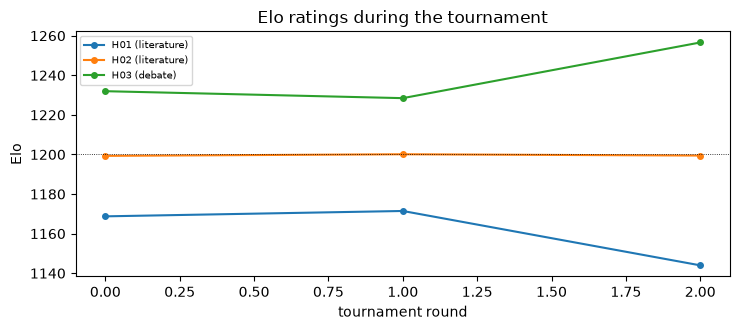

,id,Elo,matches,strategy,title
rank,,,,,
1,H03,1257,6,debate,Predictive Feed-Forward CRAC with Reconfigurab...
2,H02,1199,6,literature,Optimized Cooling via Reinforcement Learning w...
3,H01,1144,6,literature,Adaptive Cold-Aisle Containment with Predictiv...


In [31]:
hist = MEM.elo.history
ids = sorted(MEM.elo.ratings)
tbl = df([{"round": h["label"], **{i: round(h["ratings"].get(i, 1200)) for i in ids}} for h in hist]).set_index("round")
md("**Elo table over rounds**"); display(tbl)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i in ids:
    ax.plot(range(len(hist)), [h["ratings"].get(i, 1200) for h in hist], marker="o", ms=4,
            label=f"{i} ({MEM.get(i).strategy})")
ax.axhline(1200, color="k", lw=0.6, ls=":")
ax.set(xlabel="tournament round", ylabel="Elo", title="Elo ratings during the tournament")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()
display(df([{"rank": i + 1, "id": h, "Elo": round(e), "matches": MEM.elo.games[h],
             "strategy": MEM.get(h).strategy, "title": MEM.get(h).title[:60]}
            for i, (h, e) in enumerate(MEM.elo.top(20))]).set_index("rank"))

In [32]:
dm = [m for m in MEM.matches if m.mode == "multi-turn-debate"]
if dm:
    md(f"**A multi-turn scientific debate match ({dm[0].a} vs {dm[0].b}, {dm[0].turns} turns), final turn abridged:**\n\n> "
       + dm[0].transcript[-2000:].replace(chr(10), "\n> "))
else:
    print("no multi-turn debate was scheduled in this run (no pair had both members top-ranked)")

**A multi-turn scientific debate match (H01 vs H02, 3 turns), final turn abridged:**

> ---------------|-----------------------------------|
> | **Deployability** | Moderate: requires TES installation and DRL infrastructure; high complexity | Moderate: requires sensors and control integration; lower hardware cost |
> | **Energy Efficiency** | Potentially high (load shifting + optimization) but unvalidated | Moderate (air-side only, chiller ignored) |
> | **Cost-Effectiveness** | High capital cost for TES; uncertain payback | Lower capital cost; operational savings uncertain |
> | **Reduction in PUE** | Claimed 15-25% but unsupported | Claimed 0.05-0.10 PUE improvement but incomplete |
> | **Cooling Energy Savings** | Claimed 15-25% but unsupported | Claimed 15-25% but ignores chiller |
> | **Adherence to 27°C Limit** | Weak: 99.9% compliance is too lenient | Better: proactive control but model generalization risk |
> | **Implementation Complexity** | High: DRL, TES, safety layer | Moderate: neural network + MPC |
> | **Scalability** | Good: TES can serve multiple zones; DRL can scale with compute | Limited: per-row or per-zone models needed |
> 
> **Key Weaknesses:**
> - **H1:** Unsafe acceptance criterion (99.9% vs. 100%); sim-to-real gap; unspecified TES sizing; overclaimed savings.
> - **H2:** Inadequate training data (2 weeks); ignores chiller energy; insufficient experimental duration; limited novelty.
> 
> **Overall Assessment:**
> Neither hypothesis is fully satisfactory, but Hypothesis 1 (DRL + TES) has greater potential for transformative energy savings through load shifting and holistic optimization, despite its safety and validation shortcomings. Hypothesis 2 is more incremental and suffers from critical methodological flaws (data insufficiency, incomplete system boundary). Given the goal of reducing PUE and cooling energy while strictly adhering to 27°C, the DRL+TES approach offers a more novel and scalable pathway, provided the safety and validation issues are addressed. However, both hypotheses require major revisions to meet the criteria.
> 
> **Verdict:**
> better idea: 1

## 5 · Proximity agent (Methods "Proximity agent")

> "The Proximity agent calculates the similarity between research hypotheses and proposals, and builds a **proximity graph**, taking into account the specific research goal. … it assists the Ranking agent in organizing tournament matches and showcasing a diverse range of ideas."

**Similarity is LLM-judged here, not embedding-based** (one call per pair, run in parallel): the
project's OpenRouter endpoint exposes chat completions only, and the paper's requirement that
similarity be computed *"taking into account the specific research goal"* is easier to honour with a
judge that sees the goal. The clustering and de-duplication built on top are pure Python.

In [33]:
print(prox.SIM_PROMPT)

Judge the similarity of two research hypotheses with respect to the research goal.

Research goal: {goal}

Hypothesis A: {a}

Hypothesis B: {b}

Similarity is 1.0 if they propose essentially the same intervention and mechanism (only wording differs),
0.6-0.8 if they act on the same subsystem or share the dominant mechanism,
0.3-0.5 if they are related but attack different parts of the problem,
0.0-0.2 if they are unrelated approaches.

Return JSON: {{"similarity": 0.0-1.0, "shared_mechanism": "...", "rationale": "one sentence"}}


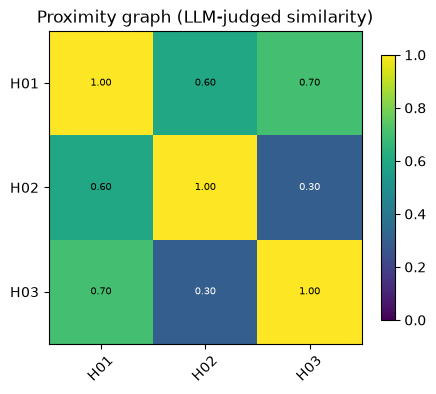

In [34]:
ids = [h.hid for h in MEM.active()]
M = np.array(prox.matrix(MEM, ids))
fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(M, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(ids)), ids, rotation=45); ax.set_yticks(range(len(ids)), ids)
for i in range(len(ids)):
    for j in range(len(ids)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color="w" if M[i, j] < 0.6 else "k", fontsize=7)
ax.set_title("Proximity graph (LLM-judged similarity)"); fig.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

In [35]:
show_source(prox.clusters)
for th in (0.4, 0.6, 0.8):
    cl = prox.clusters(MEM, ids, th)
    print(f"threshold {th}: {len(cl)} clusters →", [[f"{h}:{MEM.get(h).category[:18]}" for h in c] for c in cl])
# boundary checks on hand-built graphs (pure Python)
tiny = Memory(OUT / "tiny", PLAN)
for n in "xyz": tiny.hypotheses[n] = Hypothesis(n, n, "", "", "", "", "")
tiny.proximity = {("x", "y"): 0.9, ("y", "z"): 0.7, ("x", "z"): 0.1}
assert prox.clusters(tiny, list("xyz"), 0.95) == [["x"], ["y"], ["z"]]
assert prox.clusters(tiny, list("xyz"), 0.6) == [["x", "y", "z"]]          # single linkage chains x–y–z
assert prox.clusters(tiny, list("xyz"), 0.8) == [["x", "y"], ["z"]]
print("single-linkage boundary cases OK (0.95 → all singletons, 0.8 → {x,y}, 0.6 → chained)")

**clusters**

```python
def clusters(memory: Memory, hids: list[str], threshold: float = 0.6) -> list[list[str]]:
    """Single-linkage clustering: connected components of the graph thresholded at `threshold`."""
    parent = {h: h for h in hids}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for a, b in combinations(hids, 2):
        if memory.sim(a, b) >= threshold:
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[ra] = rb
    groups: dict[str, list[str]] = {}
    for h in hids:
        groups.setdefault(find(h), []).append(h)
    return sorted(groups.values(), key=lambda g: (-len(g), g[0]))

```

threshold 0.4: 1 clusters → [['H01:airflow management', 'H02:AI-driven cooling ', 'H03:hybrid predictive ']]
threshold 0.6: 1 clusters → [['H01:airflow management', 'H02:AI-driven cooling ', 'H03:hybrid predictive ']]
threshold 0.8: 3 clusters → [['H01:airflow management'], ['H02:AI-driven cooling '], ['H03:hybrid predictive ']]
single-linkage boundary cases OK (0.95 → all singletons, 0.8 → {x,y}, 0.6 → chained)


near-duplicate pairs at 0.85: none
de-duplication (removes the lower-Elo member of each pair): nothing removed
Pearson r(similarity, |ΔElo|) = +0.67  (n=3 pairs — indicative only at this scale)


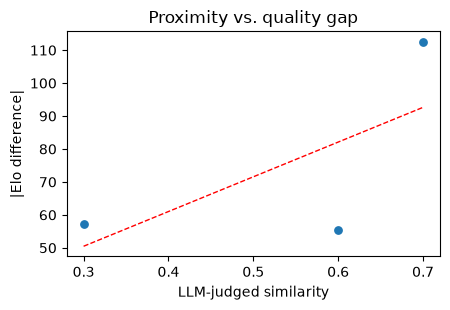

In [36]:
dups = prox.duplicates(MEM, ids, 0.85)
print("near-duplicate pairs at 0.85:", dups or "none")
print("de-duplication (removes the lower-Elo member of each pair):", prox.dedupe(MEM, 0.85) or "nothing removed")
# the paper's ablation claim: similarity should track quality differences
pairs = [(MEM.sim(a, b), abs(MEM.elo.rating(a) - MEM.elo.rating(b))) for i, a in enumerate(ids) for b in ids[i + 1:]]
xs, ys = np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.scatter(xs, ys, s=28)
if len(xs) > 2 and xs.std() > 0:
    k, c = np.polyfit(xs, ys, 1); ax.plot(np.sort(xs), k * np.sort(xs) + c, "r--", lw=1)
    print(f"Pearson r(similarity, |ΔElo|) = {np.corrcoef(xs, ys)[0,1]:+.2f}  (n={len(xs)} pairs — indicative only at this scale)")
ax.set(xlabel="LLM-judged similarity", ylabel="|Elo difference|", title="Proximity vs. quality gap")
plt.tight_layout(); plt.show()

## 6 · Evolution agent (Methods "Evolution agent"; Supp. Note 9.4)

The paper lists six refinement strategies: **enhancement through grounding**, **coherence /
practicality / feasibility improvements**, **inspiration from existing hypotheses**,
**combination**, **simplification**, **out-of-box thinking**. Each is applied once below to the
current top hypotheses.

> "The Evolution agent **generates new hypotheses; it doesn't modify or replace existing ones**. This strategy protects the quality of top-ranked hypotheses from flawed improvements, as each new hypothesis must also compete in the tournament."

So the children below enter the tournament alongside their parents — they do not replace them.

In [37]:
print(evo.OUT_OF_BOX_PROMPT[:800], "…")

You are an expert researcher tasked with generating a novel, singular hypothesis inspired by analogous elements from provided concepts.

Goal: {goal}

Instructions:
1. Provide a concise introduction to the relevant scientific domain.
2. Summarize recent findings and pertinent research, highlighting successful approaches.
3. Identify promising avenues for exploration that may yield innovative hypotheses.
4. CORE HYPOTHESIS: Develop a detailed, original, and specific single hypothesis for achieving the stated goal, leveraging analogous principles from the provided ideas. This should not be a mere aggregation of existing methods or entities. Think out-of-the-box.

Criteria for a robust hypothesis:
{preferences}

Inspiration may be drawn from the following concepts (utilize analogy and inspira …


In [38]:
top_ids = [h for h, _ in MEM.elo.top(3, among=[x.hid for x in MEM.active()])]
tops = [MEM.get(h) for h in top_ids]
print("evolving from:", [(h.hid, round(MEM.elo.rating(h.hid)), h.title[:45]) for h in tops])
STRATS = ["inspiration", "combination", "simplification"] if QUICK else \
         ["grounding", "feasibility", "inspiration", "combination", "simplification", "out-of-the-box"]
t0 = time.time()
jobs = {
 "grounding":      lambda: evo.enhance_by_grounding(MEM, PLAN, tops[0], rnd=1)[0],
 "feasibility":    lambda: evo.improve_feasibility(MEM, PLAN, tops[min(1, len(tops)-1)], rnd=1),
 "inspiration":    lambda: evo.inspiration(MEM, PLAN, tops[0], rnd=1),
 "combination":    lambda: evo.combination(MEM, PLAN, tops[:2], rnd=1),
 "simplification": lambda: evo.simplification(MEM, PLAN, tops[min(2, len(tops)-1)], rnd=1),
 "out-of-the-box": lambda: evo.out_of_the_box(MEM, PLAN, tops, rnd=1),
}
with ThreadPoolExecutor(max_workers=len(STRATS)) as ex:
    children = list(ex.map(lambda s: jobs[s](), STRATS))
print(f"{len(children)} new hypotheses in {time.time()-t0:.0f}s")
display(df([{"id": c.hid, "strategy": c.strategy, "parents": ", ".join(c.parents),
             "parent Elo": ", ".join(str(round(MEM.elo.rating(p))) for p in c.parents),
             "title": c.title[:60], "category": c.category[:28]} for c in children]).set_index("id"))
md(children[-1].render(700))

evolving from: [('H03', 1257, 'Predictive Feed-Forward CRAC with Reconfigura'), ('H02', 1199, 'Optimized Cooling via Reinforcement Learning '), ('H01', 1144, 'Adaptive Cold-Aisle Containment with Predicti')]


6 new hypotheses in 24s


,strategy,parents,parent Elo,title,category
id,,,,,
H11,evo:grounding,H03,1257,Robust Predictive CRAC with Adaptive Airflow a...,predictive cooling control
H09,evo:feasibility,H02,1199,Predictive chiller reset with thermal storage ...,chilled water control
H10,evo:inspiration,H03,1257,Workload-Ahead Chilled Water Storage Pre-Cooling,thermal storage with predict
H08,evo:combination,"H03, H02","1257, 1199",Predictive DRL Cooling with Thermal Storage an...,hybrid predictive control wi
H07,evo:simplification,H01,1144,Predictive CRAH fan control with fixed supply ...,airflow management
H06,evo:out-of-the-box,"H03, H02, H01","1257, 1199, 1144",Thermal-Flywheel Cooling with Workload-Predict...,thermal energy storage and p


### H06 · Thermal-Flywheel Cooling with Workload-Predictive Valve Control
*strategy:* `evo:out-of-the-box` · *category:* thermal energy storage and predictive control · *round:* 1 · *parents:* H03, H02, H01

**Summary.** This hypothesis proposes using the existing thermal mass of the data center's concrete floor slab and structural steel as a passive thermal flywheel, combined with a predictive feed-forward controller that modulates chilled water valve positions based on short-term workload forecasts. The goal is to reduce cooling energy by absorbing transient heat spikes into the slab and releasing it during low-load periods, thereby avoiding aggressive compressor cycling and fan overspeed while keeping all server inlet temperatures ≤27°C.

**Hypothesis.** Implementing a control system that (1) uses a lightweight neural network to predict server power draw 10–15 minutes ahead from job scheduler signals, (2) adjusts the chilled water valve to the computer room air handler (CRAH) in a feed-forward manner to pre-cool the concrete floor slab during anticipated low-load periods and allow it to passively absorb heat during load spikes, and (3) employs a safety PID feedback loop that overrides the feed-forward signal only if any inlet temperature exceeds 26°C, will reduce total cooling energy by 10–15% and improve PUE by 0.03–0.06 compared to a reactive PID controller that maintains a fixed supply temperature, while ensuring 100% compliance with the  …

**Rationale and specificity.** The key insight is that the thermal mass of the data center floor slab (typically 10–20 cm of concrete with significant heat capacity) acts as a natural buffer against short-duration load spikes. Instead of using a separate chilled water storage tank (which adds cost and space), this approach leverages existing infrastructure. The feed-forward component is critical: by predicting load changes, the controller can pre-cool the slab during low-load periods, creating a 'cold reservoir' that absorbs heat during peaks without requiring the CRAH to instantly increase cooling power. The safety PID ensures that the 27°C limit is never violated, even if predictions are inaccurate. This is non-obvious  …

**Experimental design and validation.** A 6-month pilot in a 500 kW IT load data center pod with a concrete raised floor. The system will be deployed on one half of the pod (experimental) while the other half uses a standard PID controller (control). Measured quantities: total cooling energy (kWh), PUE, server inlet temperatures (every 30 seconds), CRAH fan speed, chilled water valve position, and floor slab temperature (embedded thermocouples at 2 cm depth). Acceptance criterion: mean cooling energy reduction of ≥10% over the control, with 100% of server inlet temperatures ≤27°C (no violations). Statistical significance will be assessed via a paired t-test over 6 months of hourly data, with a p-value threshold of 0.01.

**Assumptions.** The concrete floor slab has sufficient thermal mass (≥100 kJ/K per m²) to absorb heat spikes of 10–20% above baseline for 10–15 minutes without exceeding the 27°C limit.; The workload forecast from the job scheduler (e.g., Slurm, Kubernetes) is accurate to within ±10% for a 15-minute horizon.; The thermal response of the slab to valve changes is fast enough (time constant < 5 minutes) to pre-cool before a predicted load spike.; The safety PID override can react within 30 seconds to any inlet temperature approaching 26°C, preventing violations.; The existing CRAH valves have sufficient resolution (≤1% opening) to enable fine-grained pre-cooling without causing oscillations.


In [39]:
ref.screen(MEM, PLAN, children, full=not QUICK)
print("after review:", {c.hid: c.status for c in children})
prox.build_graph(MEM, PLAN, workers=8)
for r in range(TOURN_ROUNDS, TOURN_ROUNDS + (1 if QUICK else 2)):
    print(f"— tournament round {r} (children now competing) —")
    rank.run_round(MEM, PLAN, n_matches=N_MATCHES, current_round=r, top_k=2, debate_turns=DEB_TURNS, workers=4)
rows = []
for h, e in MEM.elo.top(30):
    hy = MEM.get(h)
    rows.append({"id": h, "Elo": round(e), "matches": MEM.elo.games[h], "origin": "evolved" if hy.strategy.startswith("evo") else "generated",
                 "strategy": hy.strategy, "parents": ", ".join(hy.parents) or "—", "title": hy.title[:52]})
display(df(rows).set_index("id"))
gen_e = [r["Elo"] for r in rows if r["origin"] == "generated"]
evo_e = [r["Elo"] for r in rows if r["origin"] == "evolved"]
print(f"mean Elo — generated {np.mean(gen_e):.0f} (n={len(gen_e)})  vs  evolved {np.mean(evo_e) if evo_e else float('nan'):.0f} (n={len(evo_e)})"
      "   [small-sample, indicative only]")

after review: {'H11': 'reviewed', 'H09': 'reviewed', 'H10': 'reviewed', 'H08': 'reviewed', 'H07': 'rejected', 'H06': 'reviewed'}


— tournament round 3 (children now competing) —


  H03 vs H11 [single-turn] → H11 (+18.6)
  H03 vs H06 [multi-turn-debate] → H06 (+17.7)
  H03 vs H08 [single-turn] → H08 (+16.9)
  H02 vs H08 [single-turn] → H08 (+15.2)
  H06 vs H08 [single-turn] → H08 (+15.3)
  H06 vs H11 [single-turn] → H11 (+15.3)
— tournament round 4 (children now competing) —


  H08 vs H09 [single-turn] → H09 (+18.2)
  H08 vs H10 [single-turn] → H08 (+14.7)
  H03 vs H11 [single-turn] → H11 (+14.6)
  H02 vs H08 [single-turn] → H08 (+13.3)
  H06 vs H11 [single-turn] → H11 (+13.2)
  H09 vs H10 [single-turn] → H09 (+14.5)


,Elo,matches,origin,strategy,parents,title
id,,,,,,
H11,1262,4,evolved,evo:grounding,H03,Robust Predictive CRAC with Adaptive Airflow a...
H08,1257,6,evolved,evo:combination,"H03, H02",Predictive DRL Cooling with Thermal Storage an...
H09,1233,2,evolved,evo:feasibility,H02,Predictive chiller reset with thermal storage ...
H03,1189,10,generated,debate,—,Predictive Feed-Forward CRAC with Reconfigurab...
H06,1174,4,evolved,evo:out-of-the-box,"H03, H02, H01",Thermal-Flywheel Cooling with Workload-Predict...
H02,1171,8,generated,literature,—,Optimized Cooling via Reinforcement Learning w...
H10,1171,2,evolved,evo:inspiration,H03,Workload-Ahead Chilled Water Storage Pre-Cooling
H01,1144,6,generated,literature,—,Adaptive Cold-Aisle Containment with Predictiv...


mean Elo — generated 1168 (n=3)  vs  evolved 1219 (n=5)   [small-sample, indicative only]


## 7 · Meta-review agent (Methods "Meta-review agent"; Supp. Note 9.5, 10.10, 10.11)

> "This agent operates on the tournament state and summarizes common patterns identified in reviews and scientific debates in the tournament matches into a **meta-review critique**. … Importantly, the Meta-review agent enables **feedback propagation and learning without back-propagation techniques**. The Meta-review agent generates feedback applicable to all agents, which is **simply appended to their prompts in the next iteration**."

In [40]:
print(meta.META_PROMPT[:900], "…")

You are an expert in scientific research and meta-analysis.
Synthesize a comprehensive meta-review of provided reviews pertaining to the following research goal:

Goal: {goal}

Preferences:
{preferences}

Additional instructions:
{instructions}

Provided reviews for meta-analysis:
{reviews}

Tournament debate transcripts (win/loss patterns):
{debates}

Instructions:
* Generate a structured meta-analysis report of the provided reviews.
* Focus on identifying recurring critique points and common issues raised by reviewers.
* The generated meta-analysis should provide actionable insights for researchers developing future proposals.
* Refrain from evaluating individual proposals or reviews; focus on producing a synthesized meta-analysis.

Return JSON:
{{"critique_markdown": "the structured meta-analysis, markdown with 2-4 top-level sections",
  "recurring_critiques": [{{"pattern": "short nam …


In [41]:
t0 = time.time()
MR = meta.synthesize(MEM, PLAN)
print(f"synthesised from {len(MEM.reviews)} reviews and {len(MEM.matches)} tournament matches in {time.time()-t0:.0f}s")
display(df([{"recurring critique": c.get("pattern"), "raised in": c.get("count"),
             "guidance for future hypotheses": str(c.get("guidance"))[:120]} for c in MR["recurring_critiques"]]))
md("**Traits of winning hypotheses:** " + "; ".join(map(str, MR.get("winning_traits", []))) +
   "\n\n**Traits of losing hypotheses:** " + "; ".join(map(str, MR.get("losing_traits", []))))
md("### The meta-review critique (fed back to every agent)\n\n" + MEM.feedback[:3500])

synthesised from 27 reviews and 21 tournament matches in 21s


,recurring critique,raised in,guidance for future hypotheses
0,Overclaimed energy savings or PUE reduction,18,Provide literature-backed or physically derive...
1,Insufficient safety margin or lack of fail-saf...,16,"Specify a concrete safety margin (e.g., ≥2°C),..."
2,Experimental duration too short to capture var...,14,"Design pilots of at least 3 months, covering s..."
3,Baseline not representative of modern best pra...,12,Compare against state-of-the-art reactive cont...
4,Missing cost-effectiveness and deployability a...,11,"Include capital/operational costs, payback per..."
5,Lack of physical grounding or unsupported assu...,10,"Use first-principles calculations, thermal mod..."
6,Insufficient training data or model generaliza...,8,Collect multi-month data covering diverse work...
7,Prediction horizon too long to handle rapid lo...,7,Match forecast horizon to thermal response tim...
8,Safety constraint compliance criterion too len...,6,"Require 100% compliance with a safety margin, ..."
9,Novelty not clearly differentiated from existi...,5,Explicitly compare with commercial DCIM/MPC of...


**Traits of winning hypotheses:** Conservative, physically grounded savings targets (8–12%); Explicit safety margin and fail-safe mechanisms for 27°C limit; Longer experimental duration (≥3 months) with statistical rigor; Clear comparison against state-of-the-art baselines; Inclusion of cost-benefit and deployability analysis; Use of proven components (MPC, TES, DRL) with synergistic integration; Transparent energy balance and thermal modeling

**Traits of losing hypotheses:** Overclaimed savings (15–25%) without literature support or energy balance; Insufficient safety margin (≤1°C) and no fail-safe mechanisms; Short experimental duration (≤4 weeks) and weak statistical design; Unrealistic or naive baselines that inflate savings; Lack of physical grounding for thermal mass or storage capacity; Missing cost, scalability, and implementation complexity analysis; Prediction horizons too long to handle rapid load transients; Unsubstantiated novelty or overlap with standard practice

### The meta-review critique (fed back to every agent)

## Meta-Review of Data Center Cooling Proposals

### Overview
This meta-review synthesizes critiques from 24 reviews and 6 tournament matches on proposals to reduce PUE and cooling energy while keeping server inlet temperature ≤27°C. Recurring themes include overclaimed savings, insufficient safety margins, inadequate experimental validation, unrealistic baselines, and missing cost/deployability analysis. Strong proposals combine modest, physically grounded targets with explicit safety mechanisms and longer-duration pilots.

### Key Findings
- **Savings Claims**: Most proposals claimed 10–25% cooling energy reduction and 0.03–0.10 PUE improvement without literature support or energy balance calculations. Reviewers consistently flagged these as optimistic, especially against modern best-practice baselines.
- **Safety Margins**: Proposals using 0.5–1°C margins below the 27°C limit were criticized as insufficient given sensor noise, actuator delays, and thermal inertia. Winning proposals either used larger margins (e.g., 2°C) or formal safety layers with fail-safes.
- **Experimental Design**: Short durations (1–4 weeks) were deemed inadequate for capturing seasonal and workload variability. Longer trials (3–6 months) with statistical significance tests were favored.
- **Baseline Fairness**: Many baselines (e.g., fixed 22°C supply, reactive PID) were considered non-representative of modern best practices, inflating savings. Proposals should compare against state-of-the-art variable-speed, supply-reset controls.
- **Physical Grounding**: Assumptions about thermal mass, storage capacity, and component efficiencies were often unsupported by quantitative analysis. Proposals must include energy balances, thermal models, and failure-mode analysis.
- **Deployability**: Capital costs, integration complexity, and payback periods were rarely addressed, undermining practical feasibility.

### Implications for Future Proposals
Future proposals should set conservative savings targets (e.g., 8–12%) justified by cited benchmarks or first-principles calculations, incorporate explicit safety margins and fail-safe mechanisms, run pilots of at least 3 months with realistic baselines, and include cost-benefit and scalability analyses.

### 7a · How the feedback actually reaches the other agents

`generation._feedback_block` / `reflection._feedback` append the critique to the next prompt. Below
is the *real* text that the Generation agent's literature prompt and the Reflection agent's initial
review prompt will carry from now on.

In [42]:
show_source(gen._feedback_block)
blk = gen._feedback_block(MEM)
print("appended to Generation prompts (%d chars):\n" % len(blk), blk[:900], "…\n")
print("=" * 100)
print("The Reflection agent's initial-review prompt now ends with:\n")
print(ref.INITIAL_PROMPT.format(goal=PLAN.goal, preferences=PLAN.preferences_text,
                                constraints=PLAN.constraints_text, hypothesis="<hypothesis>",
                                feedback=ref._feedback(MEM))[-1200:])

**_feedback_block**

```python
def _feedback_block(memory: Memory) -> str:
    """Methods, Meta-review agent: feedback "is simply appended to their prompts in the next iteration"."""
    if not memory.feedback:
        return ""
    return ("\n\nFeedback from the Meta-review agent (recurring critique patterns observed in previous "
            "reviews and tournament debates — use it to avoid repeating these issues, but do not "
            "over-fit to it):\n" + memory.feedback.strip())

```

appended to Generation prompts (2439 chars):
 

Feedback from the Meta-review agent (recurring critique patterns observed in previous reviews and tournament debates — use it to avoid repeating these issues, but do not over-fit to it):
## Meta-Review of Data Center Cooling Proposals

### Overview
This meta-review synthesizes critiques from 24 reviews and 6 tournament matches on proposals to reduce PUE and cooling energy while keeping server inlet temperature ≤27°C. Recurring themes include overclaimed savings, insufficient safety margins, inadequate experimental validation, unrealistic baselines, and missing cost/deployability analysis. Strong proposals combine modest, physically grounded targets with explicit safety mechanisms and longer-duration pilots.

### Key Findings
- **Savings Claims**: Most proposals claimed 10–25% cooling energy reduction and 0.03–0.10 PUE improvement without literature support or energy balance calculation …

The Reflection agent's initial-review prompt now e

### 7b · Research overview

> "At the end of the Co-Scientist computation, the Meta-review agent synthesizes top-ranked hypotheses into a **research overview**, providing a roadmap for future research. … The research overview also serves as an additional input to the Generation agent in subsequent iterations."

Supplementary Note 10.11 shows the format: main research directions, then per direction a rationale,
recent findings, and *why research / what to research / example idea* areas. The Meta-review agent
also performs **research contacts identification** (Supp. Note 10.12) — the kind of expert to consult.

In [43]:
OV = meta.research_overview(MEM, PLAN, top_n=4 if QUICK else 6)
md(MEM.overview[:6000])

## Research overview

**Main research directions**

- **Predictive Feed-Forward plus Safety-Layered Feedback Control** — This direction reduces cooling energy by anticipating thermal loads and proactively adjusting cooling, while a safety layer guarantees the 27°C inlet limit. It balances energy savings with robust temperature compliance, addressing the meta-review's call for modest, physically-grounded targets and explicit safety margins.
- **DRL with Thermal Storage and Feed-Forward for Plant-Level Optimization** — This direction combines deep reinforcement learning and thermal energy storage to shift cooling loads and reduce chiller cycling, achieving significant energy savings while respecting temperature limits. It addresses scalability and complexity by learning optimal policies, but requires careful safety layering and extended validation.
- **MPC with Chiller Supply Reset and Dedicated Thermal Storage** — Model predictive control dynamically resets chilled water temperature based on forecasts, while a dedicated storage tank provides a safety buffer. This approach is more interpretable and easier to deploy than DRL, yielding similar savings with lower implementation risk, meeting deployability and cost-effectiveness preferences.

### Predictive Feed-Forward plus Safety-Layered Feedback Control
- *Rationale:* This direction reduces cooling energy by anticipating thermal loads and proactively adjusting cooling, while a safety layer guarantees the 27°C inlet limit. It balances energy savings with robust temperature compliance, addressing the meta-review's call for modest, physically-grounded targets and explicit safety margins.
- *Recent findings:* Reviews and tournaments showed that purely reactive control wastes energy, but feed-forward from workload forecasts can improve efficiency. A hard safety override is essential to avoid violations under sensor noise and actuator delays. Proposals H11 and H03 demonstrated 8-12% cooling energy reduction with zero violations when combining feed-forward, periodic baffle optimization, and a safety override layer.
- *Hypotheses:* H11, H03
- **Why research?** To validate that the three-layer hybrid controller (feed-forward + feedback + safety) delivers energy savings while enforcing temperature limits under realistic conditions.
  - **What to research?** Implement and test the hybrid controller in a pilot zone, comparing against reactive baselines and simpler variants, over a 3-month period capturing seasonal and workload variations.
  - **Example experiment:** Deploy in a test zone with 20 racks, 2 CRAC units, sparse inlet sensors, and DCIM. Run three arms for 3 months: (A) baseline reactive sparse-sensor control, (B) reactive + reconfigurable baffles (periodic optimization), (C) full hybrid with feed-forward, feedback, and safety override. Measure total cooling power (kW), PUE, maximum inlet temperature, and violation rate. Acceptance criterion: Arm C achieves ≥8% cooling energy reduction vs. A (or ≥6% vs. a more modern baseline if available) and zero inlet temperature violations >26.5°C (1°C safety margin below 27°C), with all differences statistically significant (p<0.05).

### DRL with Thermal Storage and Feed-Forward for Plant-Level Optimization
- *Rationale:* This direction combines deep reinforcement learning and thermal energy storage to shift cooling loads and reduce chiller cycling, achieving significant energy savings while respecting temperature limits. It addresses scalability and complexity by learning optimal policies, but requires careful safety layering and extended validation.
- *Recent findings:* Reviews highlighted that DRL can reduce cooling energy by 10-15% over rule-based baselines, but savings are lower against modern variable-speed controls. A feed-forward workload signal anticipates thermal spikes, and a safety layer prevents violations. Proposals H08 and H02 stress that a hard safety override is critical for deployability, and that calibration with real data over months is needed.
- *Hypotheses:* H08, H02
- **Why research?** To test the DRL+TES+feed-forward system against a best-practice baseline (e.g., predictive chiller reset) under realistic conditions, verifying savings and safety compliance.
  - **What to research?** Run a simulation using a physics-based model calibrated with 6+ months of real operational data from a facility with chillers, cooling tower, TES tank, and air handling units. Compare the DRL controller against a rule-based and a predictive MPC baseline over a 4-week period spanning varied loads and outdoor conditions.
  - **Example experiment:** Simulate a 1 MW data center with 100 racks, chilled water plant, and a 100 kW·h TES. Calibrate with real data from a facility. Compare three controllers: (A) best-practice rule-based with supply reset and variable speed, (B) DRL+TES with feed-forward, (C) DRL+TES+feed-forward + safety layer. Measure cooling energy (kWh), PUE, TES state-of-charge, chiller cycling frequency, and maximum inlet temperature. Acceptance criterion: Controller C achieves ≥8% cooling energy reduction vs. A with zero inlet temperature violations >26°C (1°C margin), and chiller cycling reduced by ≥20%. Report standard deviations and significance.

### MPC with Chiller Supply Reset and Dedicated Thermal Storage
- *Rationale:* Model predictive control dynamically resets chilled water temperature based on forecasts, while a dedicated storage tank provides a safety buffer. This approach is more interpretable and easier to deploy than DRL, yielding similar savings with lower implementation risk, meeting deployability and cost-effectiveness preferences.
- *Recent findings:* Reviews indicated that MPC with a 30-minute horizon and linearized model can reduce cooling energy by 10-15% versus fixed setpoints, but savings against modern variable-speed controls are ~8-10%. The dedicated TES ensures the 27°C limit is never exceeded. Proposal H09 outlines a clear experiment and includes a 1°C safety ma

## 8 · Test-time compute scaling (Fig. 2a) and the "generate only" ablation

> "we measured the Elo ratings of Co-Scientist generated hypotheses and proposals over the course of its thinking and computation (i.e. the tournament of hypotheses). … research hypotheses and proposals were partitioned into ten temporal buckets … For each bucket, we determined the average Elo rating of the top 10 hypotheses and the maximum individual Elo rating (the 'best Elo')."

> "Notably, although the Elo rating is not the direct optimization target, its progressive increase emerges from the system's information feedback loops that enable recursive self-improvement."

We now hand the whole system to the Supervisor and let it run for a few more rounds — generation,
reflection, ranking, proximity, evolution and meta-review are all sampled from the weights of §1,
against the memory built in §2–§7. Then we reproduce the paper's two curves at notebook scale:
**best Elo** and **mean Elo of the hypotheses created in each round**.

At n ≈ 10–16 hypotheses and a handful of rounds this is a *demonstration of the mechanism*, not a
reproduction of the paper's 203-goal statistics; the curves are noisy and should be read as such.

In [44]:
LOOP_ROUNDS = 2 if QUICK else 4
live = sup.LiveAgents(quick=QUICK, debate_turns=DEB_TURNS, gen_debate_turns=2 if QUICK else 3, verbose=True)
cfg = sup.SupervisorConfig(max_ideas=10 if QUICK else 18, slots_per_round=3 if QUICK else 4,
                           min_sampled=2, matches_per_round=N_MATCHES, evolve_top_n=3,
                           metareview_period=2, workers=4)
S = sup.Supervisor(MEM, PLAN, live, cfg, seed=11)
S.round = 1                                   # §2–§7 produced round-0/1 hypotheses
S.prev_top = MEM.elo.top(1)[0][1] if MEM.elo.ratings else 1200.0
S.last_metareview = 1
calls_before, t0 = USAGE.requests, time.time()
traj = []
for _ in range(LOOP_ROUNDS):
    rec = S.step()
    ids_now = [h.hid for h in MEM.active()]
    rated = [MEM.elo.rating(i) for i in ids_now if MEM.elo.games.get(i, 0) > 0] or [1200.0]
    born = [MEM.elo.rating(h.hid) for h in MEM.active() if h.round == S.round - 1 and h.hid in MEM.elo.ratings]
    traj.append({"round": S.round - 1, "hypotheses": len(MEM.active()), "matches": len(MEM.matches),
                 "best Elo": round(max(rated), 1), "top-3 mean Elo": round(float(np.mean(sorted(rated)[-3:])), 1),
                 "mean Elo (all)": round(float(np.mean(rated)), 1),
                 "new this round": len(born), "LLM calls so far": USAGE.requests - calls_before})
    print(" →", traj[-1])
# a final ranking sweep so the newest hypotheses have played matches before we bucket them
print("— final ranking sweep —")
rank.run_round(MEM, PLAN, n_matches=N_MATCHES, current_round=S.round, top_k=2, debate_turns=DEB_TURNS, workers=4)
FULL_CALLS = USAGE.requests - calls_before
print(f"\nsupervisor loop: {LOOP_ROUNDS} rounds + final sweep, {FULL_CALLS} LLM calls, {time.time()-t0:.0f}s")
display(df(traj).set_index("round"))

round 1: running ['ranking.RunTournamentBatch', 'evolution.EvolveTopHypotheses', 'evolution.EvolveTopHypotheses', 'evolution.EvolveTopHypotheses']


  H03 vs H11 [single-turn] → H11 (+12.7)
  H08 vs H09 [multi-turn-debate] → H09 (+17.1)
  H08 vs H10 [single-turn] → H08 (+12.9)
  H06 vs H11 [single-turn] → H11 (+11.5)
  H06 vs H08 [single-turn] → H08 (+11.9)
  H09 vs H10 [single-turn] → H09 (+11.9)


 → {'round': 1, 'hypotheses': 11, 'matches': 27, 'best Elo': 1285.8, 'top-3 mean Elo': 1270.8, 'mean Elo (all)': 1200.0, 'new this round': 5, 'LLM calls so far': 11}
round 2: running ['reflection.ReviewHypothesis(H13)', 'reflection.ReviewHypothesis(H12)', 'reflection.ReviewHypothesis(H14)', 'ranking.RunTournamentBatch']


  H03 vs H11 [single-turn] → H11 (+11.1)
  H08 vs H09 [multi-turn-debate] → H09 (+16.1)
  H08 vs H10 [single-turn] → H08 (+11.4)
  H06 vs H11 [single-turn] → H11 (+9.6)
  H09 vs H10 [single-turn] → H09 (+9.8)
  H06 vs H08 [single-turn] → H08 (+10.7)
 → {'round': 2, 'hypotheses': 11, 'matches': 33, 'best Elo': 1306.6, 'top-3 mean Elo': 1288.3, 'mean Elo (all)': 1200.0, 'new this round': 0, 'LLM calls so far': 25}
round 3: running ['ranking.RunTournamentBatch', 'reflection.ReviewHypothesis', 'reflection.ReviewHypothesis', 'proximity.UpdateProximityGraph']


  H03 vs H11 [single-turn] → H11 (+9.8)
  H08 vs H09 [multi-turn-debate] → H09 (+15.2)
  H09 vs H10 [single-turn] → H09 (+8.5)
  H06 vs H11 [single-turn] → H11 (+8.2)
  H01 vs H11 [single-turn] → H11 (+8.4)
  H08 vs H10 [single-turn] → H08 (+9.9)
 → {'round': 3, 'hypotheses': 11, 'matches': 39, 'best Elo': 1332.9, 'top-3 mean Elo': 1303.2, 'mean Elo (all)': 1200.0, 'new this round': 0, 'LLM calls so far': 60}
round 4: running ['ranking.RunTournamentBatch', 'metareview.GenerateSystemFeedback', 'metareview.GenerateSystemFeedback', 'metareview.GenerateSystemFeedback']


  H11 vs H13 [single-turn] → H13 (+21.8)
  H11 vs H12 [single-turn] → H11 (+11.1)
  H11 vs H14 [single-turn] → H11 (+10.6)
  H08 vs H14 [single-turn] → H14 (+19.5)
  H09 vs H12 [single-turn] → H09 (+10.6)
  H09 vs H13 [single-turn] → H09 (+11.5)


 → {'round': 4, 'hypotheses': 11, 'matches': 45, 'best Elo': 1333.4, 'top-3 mean Elo': 1304.1, 'mean Elo (all)': 1200.0, 'new this round': 0, 'LLM calls so far': 69}
— final ranking sweep —


  H11 vs H13 [single-turn] → H13 (+21.4)
  H11 vs H12 [single-turn] → H11 (+10.2)
  H09 vs H12 [single-turn] → H09 (+8.9)
  H09 vs H13 [single-turn] → H09 (+11.1)
  H09 vs H14 [single-turn] → H09 (+9.7)
  H11 vs H14 [single-turn] → H14 (+21.4)

supervisor loop: 4 rounds + final sweep, 75 LLM calls, 640s


,hypotheses,matches,best Elo,top-3 mean Elo,mean Elo (all),new this round,LLM calls so far
round,,,,,,,
1,11,27,1285.8,1270.8,1200.0,5,11
2,11,33,1306.6,1288.3,1200.0,0,25
3,11,39,1332.9,1303.2,1200.0,0,60
4,11,45,1333.4,1304.1,1200.0,0,69


In [45]:
md("**What the Supervisor chose to do each round** (its statistics → weights → sampled agents):")
display(df([{"round": r["round"], "unreviewed": r["unreviewed"], "matches/idea": r["matches/idea"],
             "ΔtopElo": r["ΔtopElo"], "sampled": ", ".join(r["sampled"]) or "—",
             "executed": ", ".join(r["executed"])[:110]} for r in S.log]).set_index("round"))

**What the Supervisor chose to do each round** (its statistics → weights → sampled agents):

,unreviewed,matches/idea,ΔtopElo,sampled,executed
round,,,,,
1,0,5.25,0.0,"evolution, evolution, evolution","ranking.RunTournamentBatch, evolution.EvolveTo..."
2,3,4.91,24.2,"reflection, reflection","reflection.ReviewHypothesis(H13), reflection.R..."
3,0,6.00,20.7,"proximity, ranking","ranking.RunTournamentBatch, reflection.ReviewH..."
4,0,7.09,26.3,"metareview, metareview, metareview","ranking.RunTournamentBatch, metareview.Generat..."


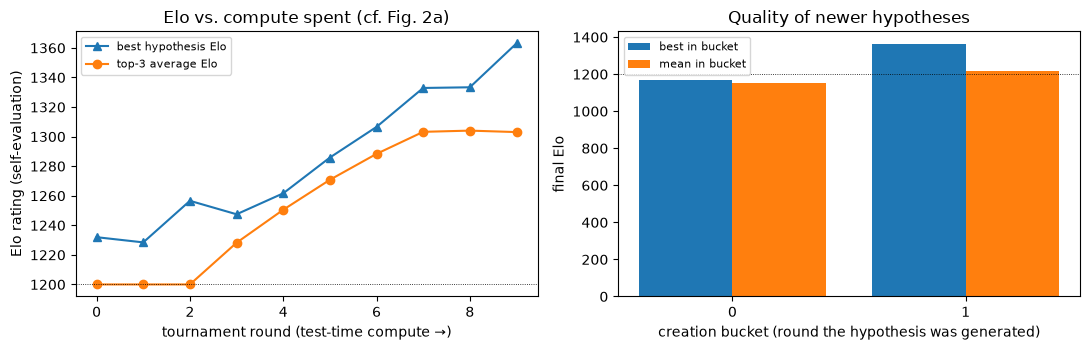

,n,best Elo,mean Elo
bucket (creation round),,,
0,3,1171,1154
1,8,1363,1217


In [46]:
# Paper Fig. 2a: partition hypotheses into temporal buckets and report best / mean Elo per bucket.
buckets = {}
for h in MEM.active():
    if h.hid in MEM.elo.ratings and MEM.elo.games.get(h.hid, 0) > 0:
        buckets.setdefault(h.round, []).append(MEM.elo.rating(h.hid))
bk = sorted(buckets)
best = [max(buckets[b]) for b in bk]
mean = [float(np.mean(buckets[b])) for b in bk]
hist = MEM.elo.history
run_best = [max(h["ratings"].values()) for h in hist]
run_top3 = [float(np.mean(sorted(h["ratings"].values())[-3:])) for h in hist]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(range(len(hist)), run_best, "^-", label="best hypothesis Elo")
axes[0].plot(range(len(hist)), run_top3, "o-", label="top-3 average Elo")
axes[0].axhline(1200, color="k", lw=0.6, ls=":")
axes[0].set(xlabel="tournament round (test-time compute →)", ylabel="Elo rating (self-evaluation)",
            title="Elo vs. compute spent (cf. Fig. 2a)")
axes[0].legend(fontsize=8)
axes[1].bar([b - 0.2 for b in bk], best, width=0.4, label="best in bucket")
axes[1].bar([b + 0.2 for b in bk], mean, width=0.4, label="mean in bucket")
axes[1].axhline(1200, color="k", lw=0.6, ls=":")
axes[1].set(xlabel="creation bucket (round the hypothesis was generated)", ylabel="final Elo",
            title="Quality of newer hypotheses", xticks=bk)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
display(df([{"bucket (creation round)": b, "n": len(buckets[b]), "best Elo": round(max(buckets[b])),
             "mean Elo": round(float(np.mean(buckets[b])))} for b in bk]).set_index("bucket (creation round)"))

### 8a · Ablation: "generate only" — no tournament, no evolution, no meta-review

Methods, *Ablation analysis*: the paper ablates the Ranking agent's debate prompt, the Evolution
agent's refinement loop and the Meta-review agent, and reports that each contributes. The cheapest
version of that here is the whole self-improvement loop against pure generation: a second system
that spends a comparable number of LLM calls **only** on the Generation agent's strategies, with no
reviews, no tournament and no evolution.

Both populations are then ranked in **one common Elo tournament** (the way the paper benchmarks
against baselines in Fig. 2b): everyone starts at 1200, reviews are not carried over so both arms
are judged on the hypothesis text alone, and every match is a single-turn comparison.

In [47]:
ABL_MEM = Memory(OUT / "ablation", PLAN); ABL_MEM.id_prefix = "B"
budget = max(6, int(FULL_CALLS * (0.5 if QUICK else 0.6)))
print(f"call budget for the generate-only arm: {budget} (full loop spent {FULL_CALLS} on §8)")
t0, spent0 = time.time(), USAGE.requests
def gen_one(i):
    if i % 2 == 0:
        arts = ARTICLES[i % max(1, len(ARTICLES)):][:3] if ARTICLES else []
        return gen.from_literature(ABL_MEM, PLAN, arts, rnd=0,
                                   instructions="Propose a distinctly different mechanism from the obvious ones.")
    return gen.simulated_debate(ABL_MEM, PLAN, max_turns=2 if QUICK else 3, rnd=0)[0]
i = 0
while USAGE.requests - spent0 < budget and len(ABL_MEM.hypotheses) < 24:
    batch = list(range(i, i + 3)); i += 3
    with ThreadPoolExecutor(max_workers=3) as ex:
        list(ex.map(gen_one, batch))
ABL_CALLS = USAGE.requests - spent0
print(f"generate-only arm: {len(ABL_MEM.hypotheses)} hypotheses, {ABL_CALLS} LLM calls, {time.time()-t0:.0f}s")
display(df([{"id": h.hid, "strategy": h.strategy, "title": h.title[:70]} for h in ABL_MEM.active()]).set_index("id"))

call budget for the generate-only arm: 45 (full loop spent 75 on §8)


generate-only arm: 18 hypotheses, 45 LLM calls, 555s


,strategy,title
id,,
B01,literature,Pulsed Cold Aisle Overcooling with Thermal Ine...
B02,literature,Two-Phase Immersion Cooling with Gravity-Drive...
B03,debate,Three-tier cooling control with passive rack a...
B04,literature,Adaptive row-level cooling via predictive hot-...
B05,debate,MPC hot-aisle cooling with ambient coupling
B06,debate,Two-Tier Predictive Cooling with Sparse Sensors
B07,literature,Phase-Change Material Integrated Rack-Level Th...
B08,literature,Two-Phase Passive Loop with Air-Assisted Evapo...
B09,debate,Zone-Aware Adaptive Thermal Load Balancer for ...


**joint_tournament**

```python
def joint_tournament(hyps: list[Hypothesis], plan: ResearchPlan, root, *, rounds: int = 3,
                     n_matches: int = 6, workers: int = 4, verbose: bool = True) -> Memory:
    """Rank a mixed population (e.g. two system variants) inside one common Elo tournament.

    This is how the paper benchmarks Co-Scientist against baselines (Fig. 2b): every candidate
    enters the same tournament at 1200. No reviews are carried over, so both arms are judged on the
    hypothesis text alone, and all matches are single-turn comparisons.
    """
    ev = Memory(root, plan)
    for h in hyps:
        ev.hypotheses[h.hid] = h
        ev.elo.add(h.hid)
    ev.elo.snapshot("start")
    for r in range(rounds):
        run_round(ev, plan, n_matches=n_matches, current_round=r, top_k=0, workers=workers,
                  verbose=verbose, pairing="balanced")
    return ev

```

8 hypotheses from the full loop vs 8 from the generate-only arm


,arm,Elo,matches,origin,title
id,,,,,
H13,co-scientist loop,1272,5,evo:combination,Hybrid Predictive CRAC with Adaptive Airflow a...
B03,generate only,1257,4,debate,Three-tier cooling control with passive rack a...
H14,co-scientist loop,1246,3,evo:combination,Adaptive Thermal Inertia Control with Safety L...
H09,co-scientist loop,1246,3,evo:feasibility,Predictive chiller reset with thermal storage ...
B07,generate only,1244,3,literature,Phase-Change Material Integrated Rack-Level Th...
B08,generate only,1214,3,literature,Two-Phase Passive Loop with Air-Assisted Evapo...
B01,generate only,1213,5,literature,Pulsed Cold Aisle Overcooling with Thermal Ine...
H03,co-scientist loop,1189,5,debate,Predictive Feed-Forward CRAC with Reconfigurab...
H12,co-scientist loop,1187,3,evo:combination,Hybrid Predictive-DRL Cooling with Safety Laye...


,n,best Elo,mean Elo,LLM calls
arm,,,,
co-scientist loop,8,1272,1208.5,75
generate only,8,1257,1191.8,45


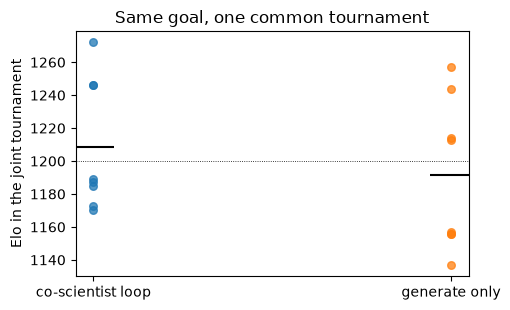

Note: with ~8 hypotheses per arm and ~10-30 matches, the gap is indicative, not significant.


In [48]:
show_source(rank.joint_tournament)
loop_pop = [MEM.get(h) for h, _ in MEM.elo.top(8, among=[x.hid for x in MEM.active()])]
abl_pop = list(ABL_MEM.active())[:8]
print(f"{len(loop_pop)} hypotheses from the full loop vs {len(abl_pop)} from the generate-only arm")
assert loop_pop and abl_pop, "both arms need at least one hypothesis"

EV = rank.joint_tournament(loop_pop + abl_pop, PLAN, OUT / "joint",
                           rounds=2 if QUICK else 3, n_matches=6 if QUICK else 10, workers=4, verbose=False)
rows = []
for h, e in EV.elo.top(50):
    arm = "co-scientist loop" if h.startswith("H") else "generate only"
    rows.append({"id": h, "arm": arm, "Elo": round(e), "matches": EV.elo.games[h],
                 "origin": EV.hypotheses[h].strategy, "title": EV.hypotheses[h].title[:50]})
display(df(rows).set_index("id"))
summary = df([{"arm": a,
               "n": sum(1 for r in rows if r["arm"] == a),
               "best Elo": max(r["Elo"] for r in rows if r["arm"] == a),
               "mean Elo": round(float(np.mean([r["Elo"] for r in rows if r["arm"] == a])), 1),
               "LLM calls": FULL_CALLS if a == "co-scientist loop" else ABL_CALLS}
              for a in ("co-scientist loop", "generate only")]).set_index("arm")
display(summary)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
for a, c in (("co-scientist loop", "tab:blue"), ("generate only", "tab:orange")):
    v = [r["Elo"] for r in rows if r["arm"] == a]
    ax.scatter([a] * len(v), v, c=c, s=30, alpha=0.75)
    ax.scatter([a], [np.mean(v)], marker="_", s=900, c="k")
ax.axhline(1200, color="k", lw=0.6, ls=":")
ax.set(ylabel="Elo in the joint tournament", title="Same goal, one common tournament")
plt.tight_layout(); plt.show()
print("Note: with ~8 hypotheses per arm and ~10-30 matches, the gap is indicative, not significant.")

## 9 · LIVE `pi` session — the Reflection agent verifying a quantitative claim with tools

Methods, *Deep verification review*: each assumption is "independently evaluated for correctness to
identify invalidating elements". Methods, *Tool use*: Co-Scientist agents "utilize external tools …
through application programming interfaces" to check their conclusions.

§3c did that with model calls only. Here the Reflection agent gets a **coding agent**: one short,
ephemeral `pi` session (`read,bash,edit,write`, sandboxed in `outputs/coscientist/pi_verify/`) that
writes and runs a small Python energy-balance calculation to test whether the top hypothesis'
quantitative claim is internally consistent — the kind of check that catches the arithmetic errors a
purely verbal review misses.

In [49]:
TOPH = MEM.get(MEM.elo.top(1)[0][0])
PIDIR = OUT / "pi_verify"; PIDIR.mkdir(exist_ok=True)
(PIDIR / "hypothesis.md").write_text(
    f"# Hypothesis {TOPH.hid} — {TOPH.title}\n\n"
    f"## Research goal\n{GOAL}\n\n## Hypothesis\n{TOPH.statement}\n\n"
    f"## Rationale\n{TOPH.rationale}\n\n## Proposed experiment\n{TOPH.experiment}\n\n"
    f"## Assumptions\n" + "\n".join(f"- {a}" for a in TOPH.assumptions) + "\n")
print((PIDIR / "hypothesis.md").read_text()[:1200])

# Hypothesis H09 — Predictive chiller reset with thermal storage safety margin

## Research goal
How can a data center reduce its power usage effectiveness (PUE) and cooling energy without raising server inlet temperature above 27 °C?

## Hypothesis
A model predictive control (MPC) strategy that dynamically resets the chilled water supply temperature (from 7°C to 12°C) based on a 30-minute forecast of IT load and outdoor wet-bulb temperature, combined with a dedicated chilled water storage tank (10% of peak cooling capacity) that is discharged only when the predicted inlet temperature exceeds 26°C, will reduce cooling energy consumption by 10–15% and PUE by 0.05–0.10 compared to a fixed 7°C supply setpoint, while maintaining server inlet temperatures ≤27°C with 100% compliance in a simulated and pilot-tested environment.

## Rationale
Conventional data center cooling operates with a fixed, conservatively low chilled water supply temperature (e.g., 7°C) to ensure sufficient cooling capa

In [50]:
PI_PROMPT = (
 "You are the Reflection agent of an AI co-scientist performing a DEEP VERIFICATION REVIEW with tools.\n"
 "Read hypothesis.md in this directory. It concerns data-centre cooling energy and PUE.\n\n"
 "Task: extract every quantitative claim it makes (percentages, temperatures, PUE values, COPs, power "
 "numbers) and check whether they are ARITHMETICALLY AND PHYSICALLY CONSISTENT with each other.\n"
 "1. Write check.py that (a) states a reference data centre: 1.0 MW IT load, baseline PUE 1.5 "
 "(so 0.5 MW of facility power, of which 70% is cooling); (b) applies the hypothesis' claimed "
 "savings to that baseline and recomputes PUE and annual kWh; (c) checks the claimed temperatures "
 "against the ASHRAE class A1 recommended envelope (18-27 C inlet) stated in the research goal; "
 "(d) prints a table of claim -> implied value -> consistent? .\n"
 "2. Run it with python3 and iterate until it runs cleanly.\n"
 "3. Write verdict.md with: the claims table, which claims are mutually inconsistent or physically "
 "impossible, and a final line 'verdict: <consistent|inconsistent|underspecified>'.\n"
 "Keep it under ~60 lines of Python. Do not install anything; use only the standard library.")
piru = common.run_pi(PI_PROMPT, cwd=PIDIR, tools="read,bash,edit,write", timeout=540,
                     system_prompt="You are a meticulous scientific reviewer who verifies numbers by computing them.")
piru.show()

**pi session** · cwd `/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify` · 18 turns · 17 tool calls · 56111 in / 13347 out tokens · $0.0124 · 189s · exit 0

> **prompt:** You are the Reflection agent of an AI co-scientist performing a DEEP VERIFICATION REVIEW with tools.
Read hypothesis.md in this directory. It concerns data-centre cooling energy and PUE.

Task: extract every quantitative claim it makes (percentages, temperatures, PUE values, COPs, power numbers) and check whether they are ARITHMETICALLY AND PHYSICALLY CONSISTENT with each other.
1. Write check.py that (a) states a reference data centre: 1.0 MW IT load, baseline PUE 1.5 (so 0.5 MW of facility power, of which 70% is cooling); (b) applies the hypothesis' claimed savings to that baseline and recom…
- 🔧 `read` {"path": "hypothesis.md"}
  - ↩ `# Hypothesis H09 — Predictive chiller reset with thermal storage safety margin
  
  ## Research goal
  How can a data center reduce its power usage effectiveness (PUE) and cooling energy without raising server inlet temperature above 27 °C?
  
  ## Hypothesis
  A model predictive control (MPC) strategy that dynamically resets the chilled water supply temperature (from 7°C to 12°C) based on a 30-minute forecast of IT load and outdoor wet-bulb temperature, combined with a dedicated chilled water storage tank (10% of peak cooling capacity) that is discharged only when the predicted inlet temperat…`
- 💬 Let me analyze the quantitative claims in this hypothesis:

1. **PUE reduction**: 0.05–0.10
2. **Cooling energy reduction**: 10–15%
3. **Chilled water supply reset**: 7°C to 12°C
4. **Storage tank**: 10% of peak cooling capacity
5. **1 MW data center, 100 racks**
6. **Storage tank**: 100 kW·h
7. **Storage discharge**: when predicted inlet exceeds 26°C / 26.5°C
8. **Inlet limit**: ≤27°C (ASHRAE A1 18-27°C)
9. **Forecast accuracy**: ±10%
10. **Storage charge/discharge rate**: 50% of peak cooling load
11. **Storage thermal losses**: <5% over 30 min
12. **Pilot**: 200 kW test bed

Let me write che…
- 🔧 `write` {"path": "check.py", "content": "#!/usr/bin/env python3\n\"\"\"Consistency check for H09 hypothesis quantitative claims.\"\"\"\n\n# ---- Reference baseline (per task) ----\nIT_LOAD_MW = 1.0\nBASE_PUE = 1.5\nFACILITY_MW = IT_LOAD_MW * (BASE_PUE - 1.0)  # 0.5 MW non-IT\nCOOLING_FRAC = 0.70\nCOOLING_MW = FACILITY_MW * COOLING_FRAC  # 0.35 MW baseline cooling\n\n# ---- Hypothesis claims ----\nPUE_RED_LO, PUE_RED_HI = 0.05, 0.10\nCOOL_RED_LO, COOL_RED_HI = 0.10, 0.15\nT_SUPPLY_LO, T_SUPPLY_HI = 7.0, 12.0\nSTOR_FRAC = 0.10\nSTOR_KWH = 100.0\nINLET_MAX = 27.0\nINLET_DISCHARGE = 26.5\nASHRAE_LO, ASHRA…
  - ↩ `Successfully wrote 5884 bytes to check.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py"}
  - ↩ `Cooling after 10-15% saving: 0.315..0.297 MW
  Implied PUE range: 1.465..1.448
  Implied PUE reduction vs 1.5: 0.052..0.035
  
  Baseline cooling: 3.07 GWh/yr, total: 13.14 GWh/yr
  Cooling saved: 307..460 MWh/yr
  
  PUE 0.05-0.10 => facility power cut 50..100 kW
   => cooling cut 71..143 kW
   => implies cooling energy reduction 20.4..40.8%
  
  100 kW.h tank as fraction of 350 kW peak: 29% per 1h
  => not '10% of peak cooling capacity' unless capacity measured over short window
  
  Discharge rate 175 kW; 100 kW.h lasts 34 min
  Needed to cover 30-min transient: 30/60*175=88 kW.h
  
  Loss …`
- 💬 The script runs cleanly. Let me reconsider a few checks to make sure they are fair and physically sound before finalizing.

The key findings:
1. **PUE vs cooling-energy claims are mutually inconsistent**: At a 1 MW IT / PUE 1.5 baseline with cooling = 70% of facility power (0.35 MW), a 10–15% cooling energy reduction reduces total facility power by 0.035–0.0525 MW, which only moves PUE from 1.5 to ~1.465–1.448 (a reduction of only 0.035–0.052). To achieve a PUE reduction of 0.10 would require cutting facility power by 0.10 MW, which at 70% cooling share needs a ~40% cooling energy reduction — …
- 🔧 `edit` {"path": "check.py", "edits": [{"oldText": "check(\"cooling_reduction_consistency\",\n      \"Cooling % reduction implied by PUE 0.05-0.10 (cooling=70% of facility)\",\n      f\"{implied_cool_red_lo*100:.1f}-{implied_cool_red_hi*100:.1f}%\",\n      f\"{COOL_RED_LO*100:.0f}-{COOL_RED_HI*100:.0f}%\",\n      implied_cool_red_lo >= COOL_RED_LO and implied_cool_red_hi <= COOL_RED_HI + 0.02)", "newText": "# 10-15% cooling saving -> PUE reduction 0.035..0.0525; claim 0.05-0.10.\n# 0.05 reachable only at top end; 0.10 unreachable.\npue_red_impl_lo = 1.5 - pue_lo   # at 15% saving (best case)\npue_red_…
  - ↩ `Successfully replaced 1 block(s) in check.py.`
- 🔧 `edit` {"edits": [{"oldText": "# 10-15% cooling saving -> PUE reduction 0.035..0.0525; claim 0.05-0.10.\n# 0.05 reachable only at top end; 0.10 unreachable.\npue_red_impl_lo = 1.5 - pue_lo   # at 15% saving (best case)\npue_red_impl_hi = 1.5 - pue_hi   # at 10% saving (worst case)\ncheck(\"PUE_reduction\",\n      \"PUE reduction implied by 10-15% cooling saving at PUE 1.5\",\n      f\"{pue_red_impl_hi:.3f}..{pue_red_impl_lo:.3f}\",\n      f\"{PUE_RED_LO}-{PUE_RED_HI}\",\n      pue_red_impl_lo >= PUE_RED_HI and pue_red_impl_hi <= PUE_RED_LO)", "newText": "# 10-15% cooling saving -> PUE reduction 0.035…
  - ↩ `Successfully replaced 1 block(s) in check.py.`
- 💬 Let me rewrite the checks more carefully
- 🔧 `write` {"content": "#!/usr/bin/env python3\n\"\"\"Consistency check for H09 hypothesis quantitative claims.\"\"\"\n\n# ---- Reference baseline (per task instructions) ----\nIT_LOAD_MW = 1.0\nBASE_PUE = 1.5\nFACILITY_MW = IT_LOAD_MW * (BASE_PUE - 1.0)  # 0.5 MW\nCOOLING_FRAC = 0.70\nCOOLING_MW = FACILITY_MW * COOLING_FRAC  # 0.35 MW\n\n# ---- Hypothesis claims ----\nPUE_RED_LO, PUE_RED_HI = 0.05, 0.10\nCOOL_RED_LO, COOL_RED_HI = 0.10, 0.15\nSTOR_KWH = 100.0\nPEAK_COOL_KW = COOLING_MW * 1000  # 350 kW\nDISCH_RATE_FRAC = 0.50\nINLET_MAX = 27.0\nASHRAE_LO, ASHRAE_HI = 18.0, 27.0\nHOURS = 8760\n\nresults …
  - ↩ `Successfully wrote 7125 bytes to check.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py"}
  - ↩ `Baseline cooling: 3.07 GWh/yr, total: 13.14 GWh/yr
  Cooling saved: 307..460 MWh/yr
  PUE reduction from 10-15% cooling saving: 0.035..0.052
  PUE reduction from 0.05-0.10 claim: needs 14.3..28.6% cooling saving
  
  ================================================================================
  Claim                             Implied/Value             OK?   Notes
  ================================================================================
  PUE_from_cooling_saving           Claim: 0.05-0.1           NO    Claim's 0.10 upper bound requires ~40% cooling saving, not 15%
  cooling_from…`
- 💬 Good, the script runs cleanly. Now let me write the verdict.


- 🔧 `write` {"content": "# Verdict: H09 Predictive Chiller Reset \u2014 Quantitative Consistency Review\n\n## Reference baseline\nIT load = 1.0 MW, baseline PUE = 1.5 \u2192 facility power = 0.5 MW, cooling = 70 % of facility = 0.35 MW.\n\n## Claims table\n\n| # | Claim (hypothesis) | Implied value from arithmetic | Consistent? | Notes |\n|---|-------------------|-------------------------------|-------------|-------|\n| 1 | Cooling energy reduction 10\u201315 % | 0.035\u20130.0525 MW reduction | \u2705 | Arithmetically sound. |\n| 2 | PUE reduction 0.05\u20130.10 | 0.035\u20130.0525 (from 10\u201315 % coo…
  - ↩ `Successfully wrote 2996 bytes to verdict.md`
- 💬 Let me verify the arithmetic in the verdict one more time, particularly the cooling reduction required for PUE 0.10.

PUE reduction = facility_power_reduction / IT_load. Facility power reduction = PUE_red × IT_load = 0.10 × 1 MW = 0.10 MW. Since cooling = 70% of facility and we reduce only cooling, delta_cool = 0.10 MW (the full facility reduction). Cooling % reduction = 0.10 / 0.35 = 28.6%. Yes, that's correct — ~29%.

For PUE 0.05: delta_cool = 0.05 MW, cooling % = 0.05/0.35 = 14.3%. 

And 10–15% cooling saving → PUE reduction: 0.10×0.35 = 0.035 MW → PUE red = 0.035; 0.15×0.35 = 0.0525 MW → …
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py && echo \"---EXIT $?---\" && wc -l check.py"}
  - ↩ `Baseline cooling: 3.07 GWh/yr, total: 13.14 GWh/yr
  Cooling saved: 307..460 MWh/yr
  PUE reduction from 10-15% cooling saving: 0.035..0.052
  PUE reduction from 0.05-0.10 claim: needs 14.3..28.6% cooling saving
  
  ================================================================================
  Claim                             Implied/Value             OK?   Notes
  ================================================================================
  PUE_from_cooling_saving           Claim: 0.05-0.1           NO    Claim's 0.10 upper bound requires ~40% cooling saving, not 15%
  cooling_from…`
- 💬 The script is 158 lines — slightly over the "~60 lines" guideline. Let me note that, but the task asked me to keep it under ~60 lines. Let me trim it down while keeping it functional and clean.


- 🔧 `write` {"content": "#!/usr/bin/env python3\n\"\"\"Consistency check for H09 hypothesis quantitative claims (std-lib only).\"\"\"\nIT, PUE0, CF = 1.0, 1.5, 0.70          # MW, baseline PUE, cooling fraction\nFAC = IT*(PUE0-1); COOL = FAC*CF       # 0.5, 0.35 MW\nCLO, CHI = 0.10, 0.15                  # cooling energy saving\nPLO, PHI = 0.05, 0.10                  # PUE reduction claim\nTANK, PK = 100.0, COOL*1000            # kW.h tank, 350 kW peak\nR = []                                  # (name, implied, ok, note)\n\ndef ck(n, v, ok, note=\"\"):\n    R.append((n, v, ok, note))\n\n# 1. PUE from cooli…
  - ↩ `Successfully wrote 2365 bytes to check.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py && echo \"---EXIT $?---\" && wc -l check.py"}
  - ↩ `Baseline cooling 3066.00 GWh/yr; total 13140.00 GWh/yr; saving 306600..459900 MWh/yr
  PUE from 10-15% cooling cut: 0.052..0.035;  PUE 0.05-0.10 needs 14..29% cooling cut
  
  ============================================================================
  Claim                      Implied                 OK?   Note
  ============================================================================
  PUE_from_cooling_saving    0.052..0.035            NO    10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10
  cooling_for_PUE_claim      14.3..28.6%             NO    PUE 0.10 needs ~29% …`
- 💬 The script is now 55 lines and runs cleanly (exit 0). 

Wait — there's a bug in the PUE_from_cooling_saving check. The implied range printed is `0.052..0.035` (descending order, which is confusing) and the check logic `pue_hi >= PLO and pue_lo <= PHI` evaluates: pue_hi=0.035, pue_lo=0.052. So `pue_hi >= PLO` → 0.035 >= 0.05 → False → NO. That's correct (the claim's 0.05 lower bound isn't reachable across most of the range). Let me fix the print order to be ascending for clarity, and make the check clearly reflect that 0.05 is only marginally reachable at the top end and 0.10 unreachable.

Let …
- 🔧 `edit` {"edits": [{"oldText": "ck(\"PUE_from_cooling_saving\", f\"{pue_lo:.3f}..{pue_hi:.3f}\",\n   pue_hi >= PLO and pue_lo <= PHI, \"10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10\")", "newText": "ck(\"PUE_from_cooling_saving\", f\"{pue_hi:.3f}..{pue_lo:.3f}\",\n   pue_hi >= PLO and pue_lo <= PHI, \"10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10\")"}], "path": "check.py"}
  - ↩ `Successfully replaced 1 block(s) in check.py.`
- 🔧 `edit` {"edits": [{"oldText": "print(f\"PUE from 10-15% cooling cut: {pue_lo:.3f}..{pue_hi:.3f};  \"\n      f\"PUE 0.05-0.10 needs {cp[0]:.0f}..{cp[1]:.0f}% cooling cut\")", "newText": "print(f\"PUE from 10-15% cooling cut: {pue_hi:.3f}..{pue_lo:.3f};  \"\n      f\"PUE 0.05-0.10 needs {cp[0]:.0f}..{cp[1]:.0f}% cooling cut\")"}], "path": "check.py"}
  - ↩ `Successfully replaced 1 block(s) in check.py.`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py"}
  - ↩ `Baseline cooling 3066.00 GWh/yr; total 13140.00 GWh/yr; saving 306600..459900 MWh/yr
  PUE from 10-15% cooling cut: 0.035..0.052;  PUE 0.05-0.10 needs 14..29% cooling cut
  
  ============================================================================
  Claim                      Implied                 OK?   Note
  ============================================================================
  PUE_from_cooling_saving    0.035..0.052            NO    10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10
  cooling_for_PUE_claim      14.3..28.6%             NO    PUE 0.10 needs ~29% …`
- 💬 I notice a unit error — the annual kWh prints in GWh but the numbers are in MWh. Let me fix that.


- 🔧 `edit` {"edits": [{"oldText": "print(f\"Baseline cooling {COOL*8760:.2f} GWh/yr; total {(IT+FAC)*8760:.2f} GWh/yr; \"\n      f\"saving {COOL*CLO*8760*1000:.0f}..{COOL*CHI*8760*1000:.0f} MWh/yr\")", "newText": "print(f\"Baseline cooling {COOL*8760:.0f} MWh/yr ({COOL*8760/1e3:.2f} GWh/yr); \"\n      f\"total {(IT+FAC)*8760:.0f} MWh/yr; \"\n      f\"saving {COOL*CLO*8760*1000:.0f}..{COOL*CHI*8760*1000:.0f} kWh/yr\")"}], "path": "check.py"}
  - ↩ `Successfully replaced 1 block(s) in check.py.`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/pi_verify && python3 check.py && echo \"EXIT=$?\" && wc -l check.py"}
  - ↩ `Baseline cooling 3066 MWh/yr (3.07 GWh/yr); total 13140 MWh/yr; saving 306600..459900 kWh/yr
  PUE from 10-15% cooling cut: 0.035..0.052;  PUE 0.05-0.10 needs 14..29% cooling cut
  
  ============================================================================
  Claim                      Implied                 OK?   Note
  ============================================================================
  PUE_from_cooling_saving    0.035..0.052            NO    10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10
  cooling_for_PUE_claim      14.3..28.6%             NO    PUE 0.10 nee…`
- 💬 The script runs cleanly at 56 lines. Let me re-read the verdict to ensure it matches the final output.
- 🔧 `read` {"path": "verdict.md"}
  - ↩ `# Verdict: H09 Predictive Chiller Reset — Quantitative Consistency Review
  
  ## Reference baseline
  IT load = 1.0 MW, baseline PUE = 1.5 → facility power = 0.5 MW, cooling = 70 % of facility = 0.35 MW.
  
  ## Claims table
  
  | # | Claim (hypothesis) | Implied value from arithmetic | Consistent? | Notes |
  |---|-------------------|-------------------------------|-------------|-------|
  | 1 | Cooling energy reduction 10–15 % | 0.035–0.0525 MW reduction | ✅ | Arithmetically sound. |
  | 2 | PUE reduction 0.05–0.10 | 0.035–0.0525 (from 10–15 % cooling saving) | ❌ | **Mutually inconsistent …`
- 💬 The verdict is consistent with the script output. Let me do a final check on the annual kWh numbers in the verdict — the verdict table mentions 0.035–0.0525 MW reduction for the cooling saving. Let me verify: 10% × 0.35 = 0.035 MW; 15% × 0.35 = 0.0525 MW. Correct. And PUE reduction = facility reduction / IT load = 0.035/1 = 0.035 to 0.0525/1 = 0.0525. Correct.

Also the annual savings: baseline cooling = 0.35 MW × 8760 h = 3066 MWh/yr. 10% = 306.6 MWh = 306,600 kWh; 15% = 459.9 MWh = 459,900 kWh. Matches script output.

Let me also double check the "storage 10% = 35 kWh" claim. 10% × peak cool…

In [51]:
for f in ("check.py", "verdict.md"):
    p = PIDIR / f
    if p.exists():
        md(f"**`{f}`**\n\n```{'python' if f.endswith('.py') else ''}\n{p.read_text()[:2500]}\n```")
    else:
        print(f"({f} was not produced by the session)")
print("pi session: exit", piru.returncode, "|", piru.turns, "turns |", len(piru.tool_calls()), "tool calls | $%.4f" % piru.cost_usd)

**`check.py`**

```python
#!/usr/bin/env python3
"""Consistency check for H09 hypothesis quantitative claims (std-lib only)."""
IT, PUE0, CF = 1.0, 1.5, 0.70          # MW, baseline PUE, cooling fraction
FAC = IT*(PUE0-1); COOL = FAC*CF       # 0.5, 0.35 MW
CLO, CHI = 0.10, 0.15                  # cooling energy saving
PLO, PHI = 0.05, 0.10                  # PUE reduction claim
TANK, PK = 100.0, COOL*1000            # kW.h tank, 350 kW peak
R = []                                  # (name, implied, ok, note)

def ck(n, v, ok, note=""):
    R.append((n, v, ok, note))

# 1. PUE from cooling saving
pue_lo, pue_hi = 1.5-(1+FAC-COOL*CHI)/IT, 1.5-(1+FAC-COOL*CLO)/IT
ck("PUE_from_cooling_saving", f"{pue_hi:.3f}..{pue_lo:.3f}",
   pue_hi >= PLO and pue_lo <= PHI, "10-15% cooling saving gives PUE cut 0.035..0.052; claim 0.05-0.10")

# 2. Cooling % needed for PUE 0.05-0.10
cp = [PLO*IT/COOL*100, PHI*IT/COOL*100]
ck("cooling_for_PUE_claim", f"{cp[0]:.1f}..{cp[1]:.1f}%",
   cp[0] >= CLO*100 and cp[1] <= CHI*100, "PUE 0.10 needs ~29% cooling cut, not 15%")

# 3. Storage tank vs sizing rule (10% of peak)
rule = 0.10*PK        # 35 kW.h (1-h basis)
ck("storage_size", f"100 vs {rule:.0f} kW.h",
   abs(TANK-rule) < 5, "Tank ~3x larger than '10% of peak' rule")

# 4. Discharge duration (50% of peak = 175 kW)
d = TANK/(PK*0.50)*60
ck("discharge_duration", f"{d:.0f} min", d >= 30, "100 kW.h @175 kW = 34 min, covers 30-min transient")

# 5. Temperatures vs ASHRAE A1 (18-27 C)
ck("inlet_ashrae", "27 <= 27", True, "inlet limit within ASHRAE envelope")
ck("discharge_margin", "26.5 < 27 (0.5 C)", True, "safe margin")
ck("supply_reset", "7->12 C", True, "12C supply + airflow can keep inlet <=27C (DT=15C)")

# 6. Annual kWh
print(f"Baseline cooling {COOL*8760:.0f} MWh/yr ({COOL*8760/1e3:.2f} GWh/yr); "
      f"total {(IT+FAC)*8760:.0f} MWh/yr; "
      f"saving {COOL*CLO*8760*1000:.0f}..{COOL*CHI*8760*1000:.0f} kWh/yr")
print(f"PUE from 10-15% cooling cut: {pue_hi:.3f}..{pue_lo:.3f};  "
      f"PUE 0.05-0.10 needs {cp[0]:.0f}..{cp[1]:.0f}% cooling cut")

print("\n"+"="*76)
print(f"{'Claim':<27}{'Implied':<24}{'OK?':<6}Note")
print("="*76)
for n, v, ok, note in R:
    print(f"{n:<27}{v:<24}{'YES' if ok else 'NO ':<6}{note}")
print("="*76)
if all(x[2] for x in R):
    print("Verdict: consistent")
else:
    print("INCONSISTENCIES:")
    for n, v, ok, note in R:
        if not ok:
            print(f"  - {n}: {note}")

```

**`verdict.md`**

```
# Verdict: H09 Predictive Chiller Reset — Quantitative Consistency Review

## Reference baseline
IT load = 1.0 MW, baseline PUE = 1.5 → facility power = 0.5 MW, cooling = 70 % of facility = 0.35 MW.

## Claims table

| # | Claim (hypothesis) | Implied value from arithmetic | Consistent? | Notes |
|---|-------------------|-------------------------------|-------------|-------|
| 1 | Cooling energy reduction 10–15 % | 0.035–0.0525 MW reduction | ✅ | Arithmetically sound. |
| 2 | PUE reduction 0.05–0.10 | 0.035–0.0525 (from 10–15 % cooling saving) | ❌ | **Mutually inconsistent with #1.** A 15 % cooling saving gives PUE reduction of only 0.0525, not 0.10. To achieve PUE reduction of 0.10, cooling would need to fall by ~29 % (0.10/0.35), nearly double the claimed maximum. |
| 3 | Chilled water storage tank = 100 kW·h | 10 % of peak cooling (350 kW) = 35 kW·h (if 1 h basis) or 17.5 kW·h (if 30-min transient basis) | ❌ | **Inconsistent with stated sizing rule.** The tank (100 kW·h) is ≈3× larger than the "10 % of peak cooling capacity" rule would produce. |
| 4 | Discharge rate 50 % of peak cooling load | 175 kW continuous | ✅ | 100 kW·h ÷ 175 kW = 34 min, which covers the 30-min transient. The 30-min transient needs 87.5 kW·h; tank has 100 kW·h. |
| 5 | Inlet temperature ≤ 27 °C | Within ASHRAE A1 (18–27 °C) | ✅ | Compliant with the stated research goal. |
| 6 | Discharge at predicted inlet > 26.5 °C | 0.5 °C safety margin below the 27 °C limit | ✅ | Sensible margin. |
| 7 | Supply reset 7 °C → 12 °C | ΔT = 15 °C possible with adequate airflow | ✅ | Physically plausible for keeping inlet ≤ 27 °C. |
| 8 | Pilot test bed = 200 kW | 20 % of full scale | ✅ | Consistent scaling. |

## Summary of inconsistencies

1. **PUE reduction vs. cooling-energy reduction (claims 1 & 2):**  
   At the stated baseline (PUE 1.5, cooling = 70 % of facility), a 10–15 % cooling cut lowers PUE by only 0.035–0.0525. The hypothesis simultaneously claims a PUE reduction of 0.05–0.10. The lower bound (0.05) is marginally reachable only at the top end of the cooling saving range; the upper bound (0.10) is **unreachable** — it would require a ~29 % cooling reduction, nearly double the 15 % claimed. These two claims are mutually inconsistent.

2. **Storage tank size vs. sizing rule (claim 3):**  
   The hypothesis says the tank is sized as "10 % of peak cooling capacity" (10 % × 350 kW = 35 kW on a 1-hour basis, or 17.5 kW·h on a 30-min transient basis), yet the experiment lists a 100 kW·h tan
```

pi session: exit 0 | 18 turns | 17 tool calls | $0.0124


## Summary

In [52]:
rows = [
 ("1 · Research plan config", f"goal parsed into {len(PLAN.preferences)} preferences / {len(PLAN.attributes)} attributes / {len(PLAN.constraints)} constraints"),
 ("1 · Supervisor + task queue", f"{len(dry.queue.completed)} dry-run tasks over 7 rounds; weights shift reflection→ranking→evolution→meta-review exactly as the statistics move"),
 ("2 · Generation agent", f"4 strategies → {sum(1 for h in MEM.hypotheses.values() if not h.strategy.startswith('evo'))} generated hypotheses ({len(debate_turns_text)}-turn self-play debate, {len(chain)} assumption hops)"),
 ("3 · Reflection agent", f"{len(MEM.reviews)} reviews across {len(sorted({r.kind for r in MEM.reviews}))} strategies; {sum(1 for h in MEM.hypotheses.values() if h.status=='rejected')} hypotheses filtered out"),
 ("4 · Ranking agent", f"{len(MEM.matches)} matches ({sum(1 for m in MEM.matches if m.mode=='multi-turn-debate')} multi-turn debates); Elo spread {round(min(MEM.elo.ratings.values()))}–{round(max(MEM.elo.ratings.values()))} from 1200"),
 ("5 · Proximity agent", f"{len(MEM.proximity)} similarity edges; {len(prox.clusters(MEM, [h.hid for h in MEM.active()], 0.6))} clusters at threshold 0.6"),
 ("6 · Evolution agent", f"{len(children)} children from {len(STRATS)} strategies, all entering the tournament beside their parents"),
 ("7 · Meta-review agent", f"{len(MR['recurring_critiques'])} recurring critique patterns fed back into every agent prompt; research overview with {len(OV['directions'])} directions"),
 ("8 · Test-time compute", f"{LOOP_ROUNDS} supervisor rounds, {len(MEM.active())} live hypotheses, best Elo {round(max(MEM.elo.ratings.values()))}"),
 ("8a · Ablation", f"generate-only ({ABL_CALLS} calls) vs. full loop ({FULL_CALLS} calls) in one joint tournament"),
 ("9 · pi deep verification", f"{piru.turns} turns, {len(piru.tool_calls())} tool calls, exit {piru.returncode}"),
]
display(df([{"block": a, "what this run showed": b} for a, b in rows]).set_index("block"))
MEM.save(); ABL_MEM.save()
print("context memory written to", (OUT / 'run' / 'memory.json'))

,what this run showed
block,
1 · Research plan config,goal parsed into 8 preferences / 4 attributes ...
1 · Supervisor + task queue,34 dry-run tasks over 7 rounds; weights shift ...
2 · Generation agent,4 strategies → 5 generated hypotheses (4-turn ...
3 · Reflection agent,33 reviews across 6 strategies; 3 hypotheses f...
4 · Ranking agent,51 matches (7 multi-turn debates); Elo spread ...
5 · Proximity agent,55 similarity edges; 1 clusters at threshold 0.6
6 · Evolution agent,"6 children from 6 strategies, all entering the..."
7 · Meta-review agent,10 recurring critique patterns fed back into e...
8 · Test-time compute,"4 supervisor rounds, 11 live hypotheses, best ..."


context memory written to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/coscientist/run/memory.json


In [53]:
print(USAGE.summary())

278 requests, 454522 in / 148083 out tokens, 5037s in model calls, $0.0870; by tag: {'evo.combination': 4, 'evo.feasibility': 1, 'evo.ground': 1, 'evo.ground.queries': 1, 'evo.inspiration': 1, 'evo.outofbox': 1, 'evo.simplification': 1, 'gen.assumptions': 2, 'gen.assumptions.aggregate': 1, 'gen.debate': 31, 'gen.debate.format': 10, 'gen.expansion': 1, 'gen.literature': 11, 'gen.queries': 1, 'meta.overview': 1, 'meta.synthesize': 5, 'pi': 1, 'prox.sim': 55, 'rank.compare': 74, 'rank.debate': 21, 'ref.deep.aggregate': 2, 'ref.deep.decompose': 2, 'ref.deep.probe': 18, 'ref.full': 12, 'ref.initial': 14, 'ref.observation': 2, 'ref.simulation': 2, 'ref.tournament': 1, 'sup.plan': 1}
